In [1]:
import pandas as pd

In [228]:
#so I will aim to do catboost plus shap and sem for now

In [11]:
import os
os.chdir("D://My_projects//Drug Use//capstone//alcohol")

## Data, Independent variables, Wave I

In [2]:
import os
os.chdir("D://My_projects//Drug Use//ICPSR_21600-V25//ICPSR_21600//DS0001")

In [3]:
file_path="21600-0001-Data.tsv"

In [4]:
df = pd.read_csv(file_path, sep='\t', low_memory=False)

In [5]:
'BIO_SEX' in df

True

In [6]:
df.describe()

,AID,IMONTH,IDAY,IYEAR,SCH_YR,BIO_SEX,SMP01,SMP03,H1GI1M,H1GI1Y,...,H1WS4G,H1WS5G,H1WS6G,H1WS7G,H1WS8G,H1WS9G,H1WS10G,H1WS11G,H1WS12G,H1WS13
count,6.504000e+03,6504.000000,6504.000000,6504.000000,6504.000000,6504.000000,6504.000000,6504.000000,6504.000000,6504.000000,...,6504.0,6504.0,6504.0,6504.0,6504.0,6504.0,6504.0,6504.0,6504.0,6504.000000
mean,9.417178e+07,6.577645,15.735855,94.999846,0.354397,1.516759,0.933579,0.079951,6.604090,78.970941,...,7.0,97.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.038130
std,6.550036e+06,1.403560,8.708040,0.012400,0.483165,0.502825,0.249035,0.271238,3.905455,1.809704,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.706785
min,5.710027e+07,1.000000,1.000000,94.000000,0.000000,1.000000,0.000000,0.000000,1.000000,74.000000,...,7.0,97.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,0.000000
25%,9.257287e+07,5.000000,8.000000,95.000000,0.000000,1.000000,1.000000,0.000000,4.000000,78.000000,...,7.0,97.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.000000
50%,9.471444e+07,6.000000,15.000000,95.000000,0.000000,2.000000,1.000000,0.000000,7.000000,79.000000,...,7.0,97.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.000000
75%,9.757533e+07,8.000000,23.000000,95.000000,1.000000,2.000000,1.000000,0.000000,9.000000,80.000000,...,7.0,97.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.000000
max,9.971998e+07,12.000000,31.000000,95.000000,6.000000,6.000000,1.000000,1.000000,96.000000,96.000000,...,7.0,97.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,9.000000


In [7]:
df.isna().sum()

AID       0
IMONTH    0
IDAY      0
IYEAR     0
SCH_YR    0
         ..
PD4F      0
PD5       0
PD5A      0
AH_PVT    0
AH_RAW    0
Length: 2794, dtype: int64

In [8]:
df['IMONTH'].dtype


dtype('int64')

In [9]:
## people refused to answer if they were born in the united states!!!! a lot!!! therefore not born?? also refused to answer about their race!

In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing value ratio (top 10):")
print(df.isna().mean().sort_values(ascending=False).head(10))


Rows: 6504
Columns: 2794

Missing value ratio (top 10):
AID        0.0
IMONTH     0.0
IDAY       0.0
IYEAR      0.0
SCH_YR     0.0
BIO_SEX    0.0
VERSION    0.0
SMP01      0.0
SMP03      0.0
H1GI1M     0.0
dtype: float64


In [1]:
import os
os.chdir("D://My_projects//Drug Use//Final Thesis//alcohol")
import pandas as pd
df1=pd.read_csv('W1-4_fulldata.csv')

C:\Users\pc\AppData\Local\Temp\ipykernel_10584\2081840086.py:4: DtypeWarning: Columns (6,124,125,196,198,356,513,522,523,743,745,746,832,833,837,838,839,846,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,956,957,964,969,970,972,976,977,979,981,982,984,1000,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1063,1065,1068,1069,1070,1071,1074,1075,1076,1077,1081,1082,1083,1084,1085,1087,1088,1089,1109,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151,1174,1175,1176,1177,1180,1181,1182,1183,1184,1187,1188,1189,1190,1191,1209,1211,1212,1225,1226,1227,1228,1229,1230,1252,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1271,1290,1292,1373,1374,1380,1396,1397,1398,1399,1400,1401,1423,1424,1425,1426,1427,1428,1429,1430,1431,1432,143

In [50]:
#df3_unique = df3_unique.drop(columns=["BirthYearGroup"])
#df3_unique = df3_unique.drop(columns=['Drinking Days (Past Year)'])
#df3_unique = df3_unique.drop(columns=['Drinks per Occasion (Past Year)'])
#df3_unique = df3_unique.drop(columns=["Times Drank Alcohol (Peak Year)"])
#df3_unique = df3_unique.drop(columns=["Drinks per Occasion (Peak Year)"])
#df3_unique = df3_unique.drop(columns=["TotalDrinking"])
#df3_unique = df3_unique.drop(columns=["PeakTotalDrinking"])
#df3_unique = df3_unique.drop(columns=["GSWGT134"])
#df3_unique = df3_unique.drop(columns=["DrinksPeak"])
#df3_unique = df3_unique.drop(columns=["DrinkingDays"])
#df3_unique = df3_unique.drop(columns=["DaysPeak"])
#df3_unique = df3_unique.drop(columns=["Drinks"])
df3_unique = df3_unique.drop(columns=["Weight"])

## Target Variables, Wave IV

In [ ]:
import os
os.chdir("D://My_projects//Drug Use//ICPSR_21600-V25//ICPSR_21600//DS0022")
file_path_2="21600-0022-Data.tsv"

In [ ]:
df_2= pd.read_csv(file_path_2, sep='\t', low_memory=False)

In [ ]:
#merge the target variables with the indepemndent variables, age at first drink, number of drinking days in the past year,number of times he drinks at peak, numbr of drinks
df1['AID'] = df1['AID'].astype(str)
df_2['AID'] = df_2['AID'].astype(str)
df1 = df1.merge(
    df_2[['AID','H4TO70']],
    on='AID',
    how='left'
)


In [ ]:
df1[['H4TO70']].info()
df1[['H4TO70']].head()


In [ ]:
import numpy as np
df1['H4TO70'] = pd.to_numeric(df1['H4TO70'], errors='coerce')

df1['H4TO70'] = df1['H4TO70'].replace({
    96: np.nan,
    97: np.nan,   # legitimate skip → NaN (since we aren't using H4TO69)
    98: np.nan
})


In [ ]:
matched = df1['H4TO70'].notna().sum()
print(f"{matched} respondents had Marijuana data merged successfully.")


In [ ]:
df1 = df1.rename(columns={"H4TO70": "DaysMarijuanaPast12M_W4"})


In [ ]:
#remove missing data
targets = ['DaysMarijuanaPast12M_W4']

df1 = df1.dropna(subset=targets, how='all')


In [ ]:
df1.shape

In [3]:
dep='DaysMarijuanaPast12M_W4'

## EDA

In [17]:
#import weights dataset
import os
os.chdir("D://My_projects//Drug Use//ICPSR_21600-V25//ICPSR_21600//DS0031")
file_path_W="21600-0031-Data.tsv"
df_W = pd.read_csv(file_path_W, sep='\t', low_memory=False)

In [18]:
df_W.columns

Index(['AID', 'CLUSTER2', 'GSWGT4', 'GSWGT4_2', 'GSWGT134'], dtype='object')

In [21]:
# merge the weight variable
df_W['AID'] = df_W['AID'].astype(str)
df1 = df1.merge(
    df_W[['AID', 'GSWGT134']],
    on='AID',
    how='left'
)


In [22]:
df1['GSWGT134'].isna().sum()


np.int64(0)

In [23]:
df1['GSWGT134'].describe()


count     2210
unique    1015
top           
freq       421
Name: GSWGT134, dtype: object

## Univariate Analysis

In [253]:
#varrename
var_labels = {
    # 'TotalDrinking' dependent variable
    'H1GI8' :'Race',
    'H4TO34': 'Age at First Drink',
    'H4TO35': 'Drinking Days (Past Year)',
    'H4TO36': 'Drinks per Occasion (Past Year)',
    'H4TO44': 'Times Drank Alcohol (Peak Year)',
    'H4TO45': 'Drinks per Occasion (Peak Year)',
    'H1GI3':'Age when Moved to Current Residence',
    'H1GI1Y':'BirthYear',
    'H1GH51':'Hours of Sleep', 
    'H1ED16':'Trouble Paying Attention',
    'H1RE1':'ReligionGroup',
    'H1RE4':'LowReligiousImportance',#
    'H1ED2':'TimesSkippedSchool',
    'H1ED19':'SchoolCloseness',#
    'H1ED7':'SchoolSuspension',
    'H1ED9':'SchoolExpulsion',# along with h1ed7 they make 'DisciplinaryIndex'#
    'H1TO29':'peer_alcohol_any',
    ####sexual motivations
    'H1MO1': 'FriendsRespect_Sex',
    'H1MO3': 'Rev_FeelGuilty_Sex',
    'H1MO4': 'Rev_UpsetMother_Sex',
    'H1MO5': 'Pleasure_Sex',
    'H1MO6': 'Relax_Sex',
    'H1MO7': 'Attractive_Sex',
    'H1MO8': 'LessLonely_Sex',
    
    #####Delinquent Behavior
    'H1DS5': 'Fight_Serious',
    'H1DS6': 'InjuredSomeone',
    'H1DS8': 'DroveWithoutPermission',
    'H1DS11': 'WeaponUse_Threat',
    'H1DS12': 'SoldDrugs',
    'H1DS14': 'GroupFight',
    'H1DS15': 'PublicRowdy',
    'H1DS3': 'LiedToParents',
    ######Drinking and sknoking:
    '''H1TO1': 'EverTried_Cigarette',
    'H1TO3': 'EverSmoked_Regularly',
    'H1TO4': 'Age_StartedSmoking',
    'H1TO5': 'Days_SmokedPast30',
    'H1TO7': 'CigsPerDay_Past30',
    'H1TO13': 'DrinkWithoutAdults',
    'H1TO14': 'Age_FirstDrinkNoAdults',
    'H1TO15': 'DrinkFrequency_Past12mo',
    'H1TO16': 'DrinksPerOccasion_Past12mo'''
    #####Socioeconomic Background and Parental Education
    'H1RM1': 'Mother_Education',
    'H1RF1': 'Father_Education',
    'PA55': 'Household_Income',
    'PA56': 'Bills_Payment_Ability',
    #####sports
    #SportsParticipation_Index
    ###Psychological
    #BluesInspiteOfHelp
    #LessThanOthers
    #'Unhappy', 
    #'Lonely', 
    #'UnfriendlyPeople', 
    #'HardToStart', 
    #'NotWorthLiving'
    
    #'SchoolTrouble_Index'#
    #GPA_Index
    #ParentalWarmth_Index#
    #ParentalSupervision_Index#
   
    #"MotherEverSmoked",
   # "FatherEverSmoked",
   # "Age_FirstWholeCig",
   # "EverSmokedRegularly",
    #"Age_StartRegularSmoking",
   #"DaysSmokedPast30_W1",
   # "CigsPerDay_Past30_W1",
   # "DaysMarijuanaPast30_W4"

}
df1 = df1.rename(columns=var_labels)

In [13]:
#target variables
targets = ['DaysMarijuanaPast12M_W4']
weight = 'GSWGT134'


In [14]:
import numpy as np
import pandas as pd

def weighted_mean(x, w):
    mask = ~np.isnan(x)
    return np.average(x[mask], weights=w[mask])

def weighted_median(x, w):
    mask = ~np.isnan(x)
    x, w = x[mask], w[mask]
    srt = np.argsort(x)
    x, w = x[srt], w[srt]
    cum_w = np.cumsum(w)
    cutoff = w.sum() / 2
    return x[np.searchsorted(cum_w, cutoff)]


In [29]:
#race
var = 'Race'      

df1[weight] = pd.to_numeric(df1[weight], errors='coerce')

# Drop rows missing the variable or weight
df = df1[[var, weight]].dropna()

# Weighted counts per category
weighted_freq = (
    df1.groupby(var, as_index=False)[weight]
      .sum()
      .rename(columns={weight: 'Weighted_N'})
)
# Ensure weight is numeric
weighted_freq['Weighted_N'] = pd.to_numeric(weighted_freq['Weighted_N'], errors='coerce')
# Weighted percentage
weighted_freq['Weighted_%'] = (
    weighted_freq['Weighted_N'] / weighted_freq['Weighted_N'].sum() * 100
)

print(weighted_freq.sort_values('Weighted_%', ascending=False))


   Race    Weighted_N  Weighted_%
6     7  2.094828e+07   95.628904
0     1  4.646366e+05    2.121066
1     2  1.961568e+05    0.895456
2     3  1.384074e+05    0.631830
4     5  7.510544e+04    0.342856
3     4  4.675748e+04    0.213448
7     8  2.841004e+04    0.129692
5     6  4.777342e+03    0.021809
8     9  3.272786e+03    0.014940


In [30]:
print(df1[weight].describe())
print("Non-missing weights:", df1[weight].notna().sum())


count     4208.000000
mean      5205.752376
std       3032.693527
min        303.206328
25%       3352.976969
50%       5003.206030
75%       6560.325154
max      30769.556450
Name: Weight, dtype: float64
Non-missing weights: 4208


In [31]:
#Birth Year
var = 'BirthYear'     # or 'H1GI1Y' if not renamed yet


df = df1[[var, weight]].dropna()
x = df[var].astype(float).to_numpy()
w = df[weight].astype(float).to_numpy()


In [32]:
import numpy as np

def weighted_mean(x, w):
    mask = ~np.isnan(x)
    return np.average(x[mask], weights=w[mask])

def weighted_median(x, w):
    mask = ~np.isnan(x)
    x, w = x[mask], w[mask]
    srt = np.argsort(x)
    x, w = x[srt], w[srt]
    cum_w = np.cumsum(w)
    cutoff = w.sum() / 2
    return x[np.searchsorted(cum_w, cutoff)]

mean_ = weighted_mean(x, w)
median_ = weighted_median(x, w)
missing_ = df1[var].isna().mean() * 100

print(f"{var} – Weighted mean: {mean_:.1f}, median: {median_:.1f}, missing: {missing_:.1f}%")


BirthYear – Weighted mean: 79.1, median: 79.0, missing: 0.0%


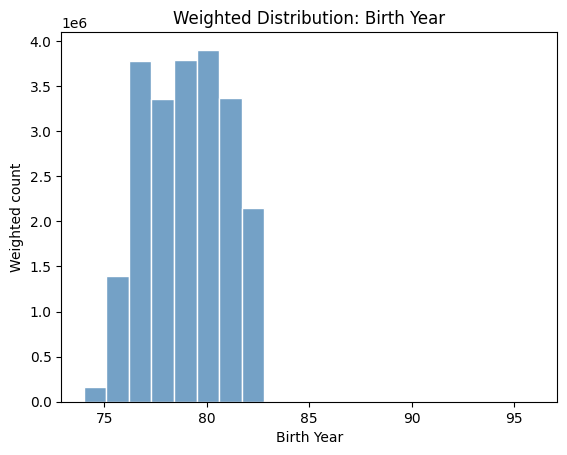

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df1, x=var, weights=weight, bins=20,
             color='steelblue', edgecolor='white')
plt.title('Weighted Distribution: Birth Year')
plt.xlabel('Birth Year')
plt.ylabel('Weighted count')
plt.show()


In [34]:
# Convert both variables and the weight to numeric, forcing blanks to NaN
df1['Age when Moved to Current Residence'] = pd.to_numeric(
    df1['Age when Moved to Current Residence'], errors='coerce'
)
df1[weight] = pd.to_numeric(
    df1[weight], errors='coerce'
)


In [35]:
#trouble paying attention attention at school
var = 'Trouble Paying Attention'


df = df1[[var, weight]].dropna()
df[var] = pd.to_numeric(df[var], errors='coerce')

weighted_freq = (
    df.groupby(var, as_index=False)[weight]
      .sum()
      .rename(columns={weight: 'Weighted_N'})
)
weighted_freq['Weighted_%'] = (
    weighted_freq['Weighted_N'] / weighted_freq['Weighted_N'].sum() * 100
)

print(weighted_freq.sort_values('Weighted_%', ascending=False))


   Trouble Paying Attention    Weighted_N  Weighted_%
1                       1.0  9.777789e+06   45.598607
0                       0.0  4.949171e+06   23.080400
2                       2.0  3.784490e+06   17.648927
3                       3.0  2.194645e+06   10.234703
4                       4.0  7.370798e+05    3.437363


 0 never
 1 just a few times
 2 about once a week
 3 almost everyday
 4 everyday


## Relations with Smoking Behavior

In [269]:
#####review
df1['Weight'] = pd.to_numeric(df1['GSWGT134'], errors='coerce')

In [36]:
import numpy as np

# Drop rows with missing values in either variable or weight
temp = df1.dropna(subset=[dep, 'Weight'])

weighted_mean = np.average(temp[dep], weights=temp['Weight'])
unweighted_mean = df1[dep].mean()

print(f"Weighted mean: {weighted_mean:.3f}")
print(f"Unweighted mean: {unweighted_mean:.3f}")


Weighted mean: 1.758
Unweighted mean: 1.707


In [38]:
import numpy as np
import pandas as pd

var = dep   # <-- use the upper bound version
group = 'Sex_Female'                  # male/female
weight = 'Weight'

# Filter and clean
df = df1[[var, group, weight]].dropna(subset=[var, group, weight])
df[weight] = pd.to_numeric(df[weight], errors='coerce')
df[var] = pd.to_numeric(df[var], errors='coerce')
df = df.dropna(subset=[weight])

# Compute weighted means by sex
weighted_means = (
    df.groupby(group)
      .apply(lambda g: np.average(g[var], weights=g[weight]))
      .reset_index(name='Weighted Mean smoking days')
)

print(weighted_means)


   Sex_Female  Weighted Mean smoking days
0           0                    2.033053
1           1                    1.391809


C:\Users\pc\AppData\Local\Temp\ipykernel_24932\3371135193.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[var], weights=g[weight]))


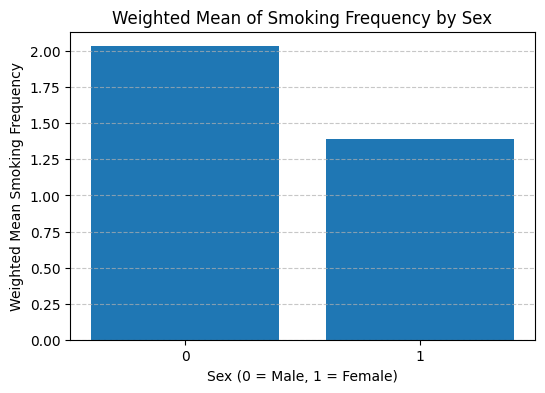

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(weighted_means[group].astype(str), weighted_means['Weighted Mean smoking days'])
plt.title('Weighted Mean of Smoking Frequency by Sex')
plt.xlabel('Sex (0 = Male, 1 = Female)')
plt.ylabel('Weighted Mean Smoking Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [27]:
df1['Sex_Female'] = (df1['BIO_SEX'] == 2).astype(int)


In [46]:
[col for col in df.columns if "smok" in col.lower()]
import pandas as pd

smok_vars = [col for col in df1.columns if "mar" in col.lower()]

pd.DataFrame({"Smoking-related variables": smok_vars})


,Smoking-related variables
0,Age_FirstMarijuana
1,Lifetime_Marijuana
2,DaysMarijuanaPast12M_W4


In [47]:
# relation between age at first drink and total drinks at peak
import numpy as np
import pandas as pd

# Extract numeric values from tuples

df1['TotalDrinking'] = pd.to_numeric(df1['TotalDrinking'], errors='coerce')


# Drop missing
temp = df1.dropna(subset=['Age_StartedSmoking','Age_FirstMarijuana', dep, 'Sex_Female', 'Weight'])


In [48]:
# Weighted correlation function
def weighted_corr(x, y, w):
    x_mean = np.average(x, weights=w)
    y_mean = np.average(y, weights=w)
    cov_xy = np.average((x - x_mean) * (y - y_mean), weights=w)
    var_x = np.average((x - x_mean)**2, weights=w)
    var_y = np.average((y - y_mean)**2, weights=w)
    return cov_xy / np.sqrt(var_x * var_y)

corr = weighted_corr(temp['Age_StartedSmoking'], temp[dep], temp['Weight'])
print(f"Weighted correlation between Age started smoking and Smoking Frequency (past year): {corr:.3f}")


Weighted correlation between Age started smoking and Smoking Frequency (past year): -0.019


In [49]:
corr = weighted_corr(temp['Age_FirstMarijuana'], temp[dep], temp['Weight'])
print(f"Weighted correlation between Age started marijuana smoking and Smoking Frequency (past year): {corr:.3f}")

Weighted correlation between Age started marijuana smoking and Smoking Frequency (past year): -0.018


In [51]:
import numpy as np
import pandas as pd

# Drop missing cases
temp = df1.dropna(subset=['Age_FirstMarijuana', dep]).copy()

# Extract variables
x = temp['Age_FirstMarijuana']
y = temp[dep]

# Unweighted correlation (standard Pearson)
corr_unweighted = x.corr(y)  # default is Pearson correlation
print(f"Unweighted correlation between Age at First Marijuan Smoking and Marijauan Smoking Frequency now: {corr_unweighted:.3f}")


Unweighted correlation between Age at First Marijuan Smoking and Marijauan Smoking Frequency now: 0.032


At the bivariate level, age at first marijuana use shows no meaningful association with current marijuana smoking frequency. Both weighted and unweighted correlations are close to zero, indicating that earlier initiation does not, by itself, translate into more frequent use later in life. This suggests that smoking behavior in adulthood is likely shaped by a combination of factors beyond age of initiation

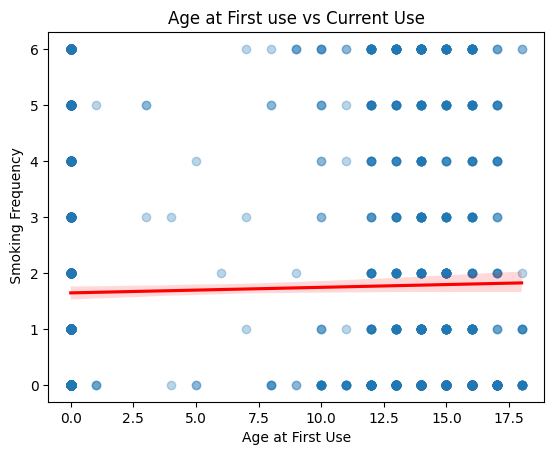

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df1,
    x='Age_FirstMarijuana',
    y=dep,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.title('Age at First use vs Current Use')
plt.xlabel('Age at First Use')
plt.ylabel(' Smoking Frequency')
plt.show()


## Correlation with Religion

In [259]:
df1 = df1.rename(columns={"H1RE3": "LessReligiousServiceAttendance_W1"})


In [260]:
df1["LessReligiousServiceAttendance_W1"].unique()


array([7, 3, 2, 1, 4, 6, 8])

In [261]:
df1["LessReligiousServiceAttendance_W1"] = df1["LessReligiousServiceAttendance_W1"].replace([6,7,8], np.nan)


In [56]:
df1[["LessReligiousServiceAttendance_W1", dep]].corr()


,LessReligiousServiceAttendance_W1,DaysMarijuanaPast12M_W4
LessReligiousServiceAttendance_W1,1.000000,0.033286
DaysMarijuanaPast12M_W4,0.033286,1.000000


In [285]:
# Convert to numeric first
df1['LowReligiousImportance'] = pd.to_numeric(df1['LowReligiousImportance'], errors='coerce')

df1['LowReligiousImportance'] = df1['LowReligiousImportance'].replace({6: np.nan, 7: np.nan, 8: np.nan})
df1['AID'] = df1['AID'].astype(str)
df['AID'] = df['AID'].astype(str)

df1['ReligionGroup'] = df1['AID'].map(df.set_index('AID')['H1RE1'])



# --- Religion type: collapse major groups for meaningful comparison ---
df1['ReligionGroup'] = df1['ReligionGroup'].map({
    0: 'None',
    4: 'Baptist',
    22: 'Catholic',
    25: 'Muslim',
    23: 'Eastern Orthodox',
    24: 'Hindu',
    21: 'Buddhist',
    26: 'Jewish',
    28: 'Other',
    # all other Protestant denominations lumped together
    1: 'Protestant', 2: 'Protestant', 3: 'Protestant', 5: 'Protestant', 6: 'Protestant',
    7: 'Protestant', 8: 'Protestant', 9: 'Protestant', 10: 'Protestant', 11: 'Protestant',
    12: 'Protestant', 13: 'Protestant', 14: 'Protestant', 15: 'Protestant', 16: 'Protestant',
    17: 'Protestant', 18: 'Protestant', 19: 'Protestant', 20: 'Protestant', 27: 'Protestant'
})


In [43]:
df1['ReligionGroup'].describe()

count           4445
unique             9
top       Protestant
freq            1843
Name: ReligionGroup, dtype: object

In [287]:
import numpy as np
import pandas as pd


# 3️⃣ Convert to numeric and set 96, 98, 99 as NaN

df1.loc[df1['ReligionGroup'].isin([96, 98, 99]), 'ReligionGroup'] = np.nan

# 4️⃣ Optional: check the result
print(df1['ReligionGroup'].value_counts(dropna=False))
print(df1['ReligionGroup'].describe())


ReligionGroup
Protestant          1843
Baptist             1270
Catholic            1096
None                 581
Other                144
NaN                   88
Jewish                39
Buddhist              19
Eastern Orthodox      15
Muslim                15
Hindu                  4
Name: count, dtype: int64
count           5026
unique            10
top       Protestant
freq            1843
Name: ReligionGroup, dtype: object


In [58]:
import numpy as np
import pandas as pd

var = dep

cols_to_convert = [var, 'Weight', 'LowReligiousImportance']

for c in cols_to_convert:
    df1[c] = pd.to_numeric(df1[c], errors='coerce')


temp = df1[[var, 'Weight', 'LowReligiousImportance']].dropna()

print(temp.shape)

print("Unique LowReligiousImportance:", temp['LowReligiousImportance'].dropna().unique())

# Weighted mean by religion importance
importance_means = (
    temp.groupby('LowReligiousImportance', group_keys=False)
        .apply(lambda g: pd.Series({'Weighted Mean Smoking Frequency': np.average(g[var], weights=g['Weight'])}),
               include_groups=False)
        .reset_index()
)



print(importance_means)




(1514, 3)
Unique LowReligiousImportance: [2. 1. 4. 3.]
   LowReligiousImportance  Weighted Mean Smoking Frequency
0                     1.0                         1.750260
1                     2.0                         1.642967
2                     3.0                         1.925992
3                     4.0                         2.066541


## Interpretation

In [61]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import pandas as pd
subset = df1[[
    dep,                     # ordinal marijuana use outcome
    'LowReligiousImportance'   # predictor
]].copy()
# Drop missing values
subset2 = subset.dropna(subset=[
    dep,
    'LowReligiousImportance'
])

# Predictor matrix
X = subset2[['LowReligiousImportance']]

# Fit ordinal logistic regression
model = OrderedModel(
    subset2[dep],
    X,
    distr='logit'
)

res = model.fit(method='bfgs', maxiter=1000)

print(res.summary())


Optimization terminated successfully.
         Current function value: 1.555492
         Iterations: 19
         Function evaluations: 20
         Gradient evaluations: 20
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -2899.4
Model:                        OrderedModel   AIC:                             5813.
Method:                 Maximum Likelihood   BIC:                             5852.
Date:                     Tue, 06 Jan 2026                                         
Time:                             11:52:59                                         
No. Observations:                     1864                                         
Df Residuals:                         1857                                         
Df Model:                                1                                         
                             coef    std err          z      P>|z|      

An ordinal logistic regression was estimated to assess whether low religious importance is associated with progression toward higher levels of marijuana use. While the estimated coefficient was positive, indicating a shift toward higher use categories, the association was not statistically significant (p = 0.236)

## Correlation with School and Engagement

In [62]:
df1['TimesSkippedSchool'].head()

0    15.0
1     3.0
2     4.0
3     0.0
4     0.0
Name: TimesSkippedSchool, dtype: float64

In [295]:
import numpy as np
import pandas as pd

# Clean H1ED2 (Times skipped school without excuse)
df1['TimesSkippedSchool'] = pd.to_numeric(df1['TimesSkippedSchool'], errors='coerce')

# Set invalid or special codes to NaN
df1.loc[df1['TimesSkippedSchool'].isin([996, 997, 998, 999]), 'TimesSkippedSchool'] = np.nan


In [63]:
df1['TimesSkippedSchool'].describe()

count    5013.000000
mean        1.852184
std         6.971288
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        99.000000
Name: TimesSkippedSchool, dtype: float64

In [64]:
import numpy as np
import pandas as pd

# 1) Create a cleaned temporary dataset (no weights)
temp = df1.dropna(subset=['TimesSkippedSchool', dep]).copy()

# 2) Extract variables as numeric arrays
x = pd.to_numeric(temp['TimesSkippedSchool'], errors='coerce')
y = pd.to_numeric(temp[dep], errors='coerce')

# Drop any rows that became NaN after coercion
mask = x.notna() & y.notna()
x = x[mask].to_numpy()
y = y[mask].to_numpy()

# 3) Unweighted Pearson correlation
corr = np.corrcoef(x, y)[0, 1]

print(f"Correlation (TimesSkippedSchool vs {dep}): {corr:.3f}")
print("N:", len(x))


Correlation (TimesSkippedSchool vs DaysMarijuanaPast12M_W4): 0.029
N: 2162


In [65]:
from scipy.stats import spearmanr

rho, p = spearmanr(x, y)
print(f"Spearman rho (TimesSkippedSchool vs {dep}): {rho:.3f}, p={p:.4g}")


Spearman rho (TimesSkippedSchool vs DaysMarijuanaPast12M_W4): 0.017, p=0.4317


In [299]:
import numpy as np

# Make sure the column exists
df1['SchoolCloseness'] = pd.to_numeric(df1['SchoolCloseness'], errors='coerce')

# Replace invalid codes with NaN
df1.loc[df1['SchoolCloseness'].isin([6,7,8]), 'SchoolCloseness'] = np.nan

# Reverse the scale so higher = stronger connection (1→5 becomes 5→1)
df1['SchoolCloseness'] = 6 - df1['SchoolCloseness']

# Quick check
df1['SchoolCloseness'].value_counts(dropna=False).sort_index()


SchoolCloseness
1.0     183
2.0     502
3.0     956
4.0    2355
5.0    1022
NaN      96
Name: count, dtype: int64

In [67]:
import pandas as pd

# Drop missing (no Weight needed)
temp = df1.dropna(subset=['SchoolCloseness', dep]).copy()

# Mean dep by closeness level
means = (
    temp.groupby('SchoolCloseness')[dep]
        .mean()
        .reset_index(name='MeanSmoking')
        .sort_values('SchoolCloseness')
)

# Also add counts (recommended)
means['N'] = temp.groupby('SchoolCloseness')[dep].size().values

print(means)



   SchoolCloseness  MeanSmoking    N
0              1.0     1.506024   83
1              2.0     1.751073  233
2              3.0     1.951111  450
3              4.0     1.625636  983
4              5.0     1.634615  416


In [68]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Predictor + outcome
X = temp[['SchoolCloseness']]
y = temp[dep].astype(int)

# Fit ordinal logit
model = OrderedModel(y, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=True)

print(res.summary())



Optimization terminated successfully.
         Current function value: 1.553245
         Iterations: 12
         Function evaluations: 15
         Gradient evaluations: 15
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3362.8
Model:                        OrderedModel   AIC:                             6740.
Method:                 Maximum Likelihood   BIC:                             6779.
Date:                     Tue, 06 Jan 2026                                         
Time:                             12:09:11                                         
No. Observations:                     2165                                         
Df Residuals:                         2158                                         
Df Model:                                1                                         
                      coef    std err          z      P>|z|      [0.025 

An ordinal logistic regression model was estimated to examine whether perceived closeness to people at school predicts progression across levels of marijuana use. The estimated effect of school closeness was small and not statistically significant (p = 0.907), indicating no evidence that school closeness is associated with marijuana use frequency once the outcome is treated as an ordered categorical variable.

In [302]:
#GPA
import numpy as np

grade_vars = ['H1ED11', 'H1ED12', 'H1ED13', 'H1ED14']

# Convert to numeric and clean
for v in grade_vars:
    df1[v] = pd.to_numeric(df1[v], errors='coerce')
    df1.loc[df1[v].isin([5,6,96,97,98,99]), v] = np.nan

# Reverse so higher = better grade
for v in grade_vars:
    df1[v] = 5 - df1[v]

# Compute GPA index
df1['GPA_Index'] = df1[[v for v in grade_vars]].mean(axis=1)

df1['GPA_Index'].describe()


count    4972.000000
mean        2.821852
std         0.763167
min         1.000000
25%         2.250000
50%         2.750000
75%         3.500000
max         4.000000
Name: GPA_Index, dtype: float64

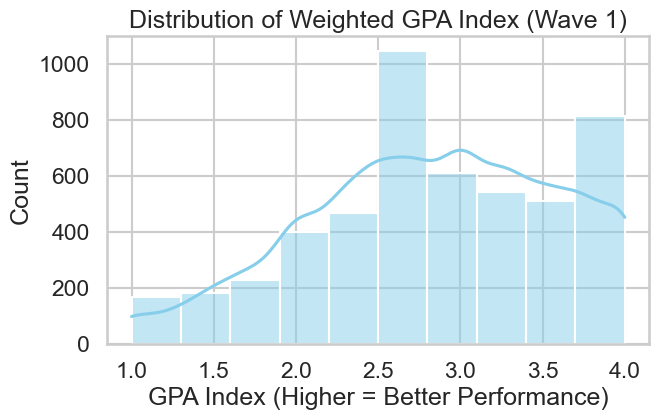

In [303]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.histplot(df1['GPA_Index'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Weighted GPA Index (Wave 1)')
plt.xlabel('GPA Index (Higher = Better Performance)')
plt.ylabel('Count')
plt.show()


In [70]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols  # unweighted regression

# 1️⃣ Drop missing
temp = df1.dropna(subset=['GPA_Index', dep]).copy()

# 2️⃣ Extract variables
x = temp['GPA_Index']
y = temp[dep]

# 3️⃣ Unweighted correlation
corr_unweighted = x.corr(y)
print(f"Unweighted correlation (GPA vs {dep}): {corr_unweighted:.3f}")

from statsmodels.miscmodels.ordinal_model import OrderedModel

y = temp[dep].astype(int)
X = temp[['GPA_Index']]

model = OrderedModel(y, X, distr='logit')
res = model.fit(method='bfgs', disp=False)
print(res.summary())


Unweighted correlation (GPA vs DaysMarijuanaPast12M_W4): -0.116
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3332.4
Model:                        OrderedModel   AIC:                             6679.
Method:                 Maximum Likelihood   BIC:                             6719.
Date:                     Tue, 06 Jan 2026                                         
Time:                             12:24:12                                         
No. Observations:                     2148                                         
Df Residuals:                         2141                                         
Df Model:                                1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
GPA_Index     -0.2194 

An ordinal logistic regression was estimated to account for the ordered nature of marijuana use frequency. GPA is negatively associated with marijuana use, with higher academic performance corresponding to lower odds of being in higher use categories (β = −0.219, p < 0.001).

In [305]:
#trouble index
import numpy as np

trouble_vars = ['H1ED15', 'Trouble Paying Attention', 'H1ED17', 'H1ED18']

# Convert and clean
for v in trouble_vars:
    df1.loc[:, v] = pd.to_numeric(df1[v], errors='coerce')
    df1.loc[df1[v].isin([6,7,8]), v] = np.nan

# Compute mean index (higher = more trouble)
df1['SchoolTrouble_Index'] = df1[trouble_vars].mean(axis=1)

df1['SchoolTrouble_Index'].describe()


count    5019.000000
mean        1.044547
std         0.721706
min         0.000000
25%         0.500000
50%         1.000000
75%         1.500000
max         4.000000
Name: SchoolTrouble_Index, dtype: float64

In [58]:
df1 = df1.rename(columns={
    'H1ED15': 'Trouble_GetAlong_Teachers_W1',
    'H1ED17': 'Trouble_HomeworkCompletion_W1',
    'H1ED18': 'TroubleGetAlong_Students_W1'
})


In [85]:
from statsmodels.formula.api import wls

import numpy as np
from scipy.stats import rankdata

temp = df1.dropna(subset=['SchoolTrouble_Index', dep, 'Weight']).copy()

x = temp['SchoolTrouble_Index']
y = temp[dep]
w = temp['Weight']

# Spearman = Pearson on ranks
x_rank = rankdata(x)
y_rank = rankdata(y)

mean_x = np.average(x_rank, weights=w)
mean_y = np.average(y_rank, weights=w)

cov_xy = np.average((x_rank - mean_x) * (y_rank - mean_y), weights=w)
corr = cov_xy / np.sqrt(
    np.average((x_rank - mean_x)**2, weights=w) *
    np.average((y_rank - mean_y)**2, weights=w)
)

print(f"Weighted Spearman correlation (School Trouble vs {dep}): {corr:.3f}")


from statsmodels.miscmodels.ordinal_model import OrderedModel

# Drop missing (NO weights here)
temp = df1.dropna(subset=['SchoolTrouble_Index', dep]).copy()

y = temp[dep].astype(int)
X = temp[['SchoolTrouble_Index']]

model = OrderedModel(y, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=False)

print(res.summary())



Weighted Spearman correlation (School Trouble vs DaysMarijuanaPast12M_W4): 0.097
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3354.0
Model:                        OrderedModel   AIC:                             6722.
Method:                 Maximum Likelihood   BIC:                             6762.
Date:                     Tue, 06 Jan 2026                                         
Time:                             13:12:38                                         
No. Observations:                     2165                                         
Df Residuals:                         2158                                         
Df Model:                                1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

Descriptive weighted correlations indicate a positive association between school trouble and marijuana use frequency. Consistent with this pattern, an ordinal logistic regression shows that higher levels of school trouble significantly increase the odds of being in more frequent marijuana-use categories (β = 0.221, p < 0.001). This suggests that school-related behavioral problems are a meaningful risk factor for more intensive marijuana use

C:\Users\pc\AppData\Local\Temp\ipykernel_24932\597131627.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(pd.cut(temp['SchoolTrouble_Index'],


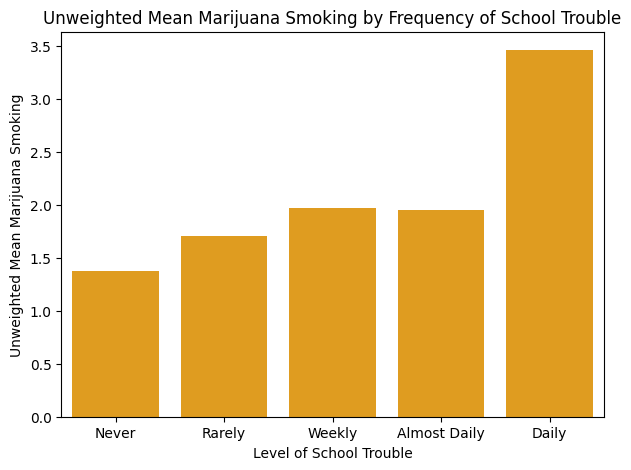

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Unweighted means by trouble category
unweighted_means = (
    temp.groupby(pd.cut(temp['SchoolTrouble_Index'], 
                        bins=[-0.1,0.5,1.5,2.5,3.5,4.5],
                        labels=['Never','Rarely','Weekly','Almost Daily','Daily']))
        [dep]
        .mean()
        .reset_index(name='UnweightedMean')
)

# Plot
plt.figure(figsize=(7,5))
sns.barplot(data=unweighted_means, x='SchoolTrouble_Index', y='UnweightedMean', color='orange')
plt.title('Unweighted Mean Marijuana Smoking by Frequency of School Trouble')
plt.xlabel('Level of School Trouble')
plt.ylabel('Unweighted Mean Marijuana Smoking')
plt.show()


In [309]:
# Convert to numeric and clean invalid codes
df1['SchoolSuspension'] = pd.to_numeric(df1['SchoolSuspension'], errors='coerce')
df1.loc[df1['SchoolSuspension'].isin([6, 8, 9]), 'SchoolSuspension'] = np.nan


In [310]:
df1['SchoolSuspension'].head()

0    0.0
1    1.0
2    1.0
3    0.0
4    1.0
Name: SchoolSuspension, dtype: float64

In [73]:
df1['SchoolSuspension'].value_counts(dropna=False)


SchoolSuspension
0.0    3728
1.0    1377
NaN       9
Name: count, dtype: int64

In [312]:
df1['SchoolSuspension'].describe()

count    5105.000000
mean        0.269736
std         0.443866
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: SchoolSuspension, dtype: float64

In [84]:
import numpy as np
from scipy.stats import rankdata

temp = df1.dropna(subset=['SchoolSuspension', dep, 'Weight']).copy()

x = temp['SchoolSuspension']
y = temp[dep]
w = temp['Weight']

# Spearman = Pearson on ranks
x_rank = rankdata(x)
y_rank = rankdata(y)

mean_x = np.average(x_rank, weights=w)
mean_y = np.average(y_rank, weights=w)

cov_xy = np.average((x_rank - mean_x) * (y_rank - mean_y), weights=w)
corr = cov_xy / np.sqrt(
    np.average((x_rank - mean_x)**2, weights=w) *
    np.average((y_rank - mean_y)**2, weights=w)
)

print(f"Weighted Spearman correlation (Suspension vs {dep}): {corr:.3f}")


Weighted Spearman correlation (Suspension vs DaysMarijuanaPast12M_W4): 0.103


In [75]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

temp = df1.dropna(subset=['SchoolSuspension', dep]).copy()

y = temp[dep].astype(int)
X = temp[['SchoolSuspension']]

model = OrderedModel(y, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=False)

print(res.summary())


                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3414.6
Model:                        OrderedModel   AIC:                             6843.
Method:                 Maximum Likelihood   BIC:                             6883.
Date:                     Tue, 06 Jan 2026                                         
Time:                             12:40:23                                         
No. Observations:                     2207                                         
Df Residuals:                         2200                                         
Df Model:                                1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
SchoolSuspension     0.4508      0.084      5.350      0.000       0.286  

Weighted descriptive correlations indicate a positive association between school suspension and marijuana use frequency. Consistent with this pattern, an ordinal logistic regression shows that students who experienced school suspension have significantly higher odds of being in more frequent marijuana-use categories (β = 0.451, p < 0.001).

C:\Users\pc\AppData\Local\Temp\ipykernel_24932\2341941947.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(
C:\Users\pc\AppData\Local\Temp\ipykernel_24932\2341941947.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weighted_means, x='SchoolSuspension', y='WeightedMean', palette='muted')


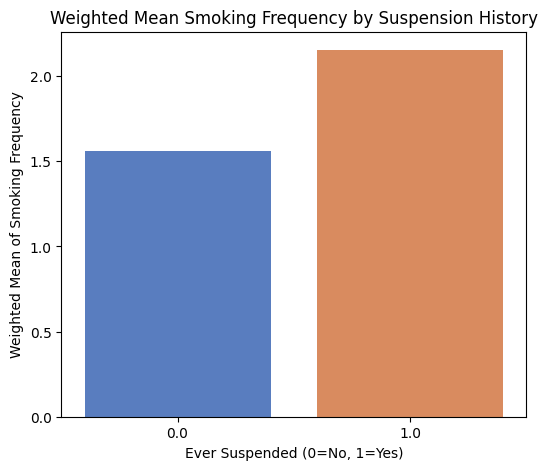

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

weighted_means = (
    temp.groupby('SchoolSuspension')
        .apply(lambda g: np.average(
            g[dep].dropna(),
            weights=g.loc[g[dep].notna(), 'Weight'].fillna(0)
        ))
        .reset_index(name='WeightedMean')
)


plt.figure(figsize=(6,5))
sns.barplot(data=weighted_means, x='SchoolSuspension', y='WeightedMean', palette='muted')
plt.title('Weighted Mean Smoking Frequency by Suspension History')
plt.xlabel('Ever Suspended (0=No, 1=Yes)')
plt.ylabel('Weighted Mean of Smoking Frequency')
plt.show()


In [316]:
#expulsion
# Convert to numeric and clean
df1['SchoolExpulsion'] = pd.to_numeric(df1['SchoolExpulsion'], errors='coerce')
df1.loc[df1['SchoolExpulsion'].isin([6, 8, 9]), 'SchoolExpulsion'] = np.nan

# Quick frequency check
df1['SchoolExpulsion'].value_counts(dropna=False)


SchoolExpulsion
0.0    4890
1.0     214
NaN      10
Name: count, dtype: int64

In [83]:
import numpy as np



import numpy as np
from scipy.stats import rankdata

temp = df1.dropna(subset=['SchoolExpulsion', dep, 'Weight']).copy()

x = temp['SchoolExpulsion']
y = temp[dep]
w = temp['Weight']

# Rank variables (Spearman = Pearson on ranks)
x_rank = rankdata(x)
y_rank = rankdata(y)

mean_x = np.average(x_rank, weights=w)
mean_y = np.average(y_rank, weights=w)

cov_xy = np.average((x_rank - mean_x) * (y_rank - mean_y), weights=w)
corr = cov_xy / np.sqrt(
    np.average((x_rank - mean_x)**2, weights=w) *
    np.average((y_rank - mean_y)**2, weights=w)
)

print(f"Weighted Spearman correlation (Expulsion vs {dep}): {corr:.3f}")


from statsmodels.miscmodels.ordinal_model import OrderedModel

temp = df1.dropna(subset=['SchoolExpulsion', dep]).copy()

y = temp[dep].astype(int)
X = temp[['SchoolExpulsion']]

model = OrderedModel(y, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=False)

print(res.summary())


Weighted Spearman correlation (Expulsion vs DaysMarijuanaPast12M_W4): 0.065
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3423.9
Model:                        OrderedModel   AIC:                             6862.
Method:                 Maximum Likelihood   BIC:                             6902.
Date:                     Tue, 06 Jan 2026                                         
Time:                             13:09:54                                         
No. Observations:                     2207                                         
Df Residuals:                         2200                                         
Df Model:                                1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------


Weighted descriptive correlations indicate a weak positive association between school expulsion and marijuana use frequency at the population level. However, ordinal logistic regression reveals a substantially stronger association at the individual level: students who experienced school expulsion have significantly higher odds of being in more frequent marijuana-use categories (β = 0.556, p = 0.002). The contrast between the small population-level correlation and the large conditional odds ratio reflects the rarity of expulsion combined with its strong association among affected students.

   SchoolExpulsion  WeightedMean
0              0.0      1.712502
1              1.0      2.573818
SchoolExpulsion
0.0    1706
1.0      80
Name: count, dtype: int64


C:\Users\pc\AppData\Local\Temp\ipykernel_24932\1506395453.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[dep], weights=g['Weight']))


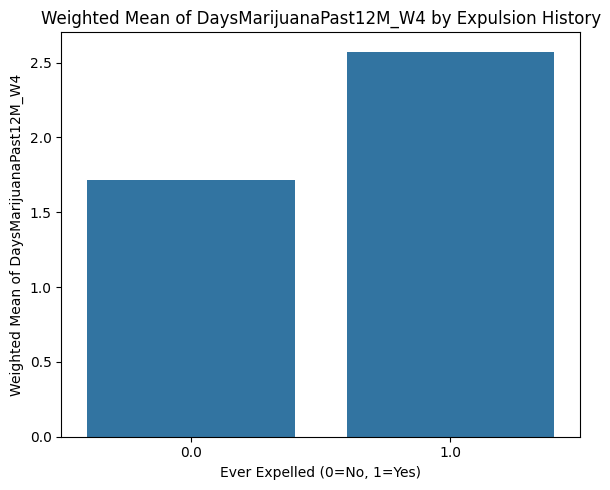

In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Rebuild temp specifically for this plot
temp = df1[['SchoolExpulsion', dep, 'Weight']].copy()

# Force numeric (prevents silent issues)
temp['SchoolExpulsion'] = pd.to_numeric(temp['SchoolExpulsion'], errors='coerce')
temp[dep] = pd.to_numeric(temp[dep], errors='coerce')
temp['Weight'] = pd.to_numeric(temp['Weight'], errors='coerce')

# Drop bad rows + nonpositive weights
temp = temp.dropna(subset=['SchoolExpulsion', dep, 'Weight'])
temp = temp[temp['Weight'] > 0]

# Weighted means by expulsion
weighted_means = (
    temp.groupby('SchoolExpulsion')
        .apply(lambda g: np.average(g[dep], weights=g['Weight']))
        .reset_index(name='WeightedMean')
)

print(weighted_means)
print(temp['SchoolExpulsion'].value_counts(dropna=False))

# Plot
plt.figure(figsize=(6,5))
ax = sns.barplot(data=weighted_means, x='SchoolExpulsion', y='WeightedMean', errorbar=None)
ax.set_title(f'Weighted Mean of {dep} by Expulsion History')
ax.set_xlabel('Ever Expelled (0=No, 1=Yes)')
ax.set_ylabel(f'Weighted Mean of {dep}')
plt.tight_layout()
plt.show()


In [320]:
df1['DisciplinaryIndex'] = df1[['SchoolExpulsion', 'SchoolSuspension']].sum(axis=1)
df1['DisciplinaryIndex'].value_counts(dropna=False)


DisciplinaryIndex
0.0    3710
1.0    1217
2.0     187
Name: count, dtype: int64

In [81]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# Weighted Spearman correlation
def weighted_spearman(x, y, w):
    """
    Compute weighted Spearman correlation.
    Spearman = Pearson correlation of ranked variables.
    """
    # Rank the variables
    x_rank = rankdata(x)
    y_rank = rankdata(y)

    # Weighted means of ranks
    x_mean = np.average(x_rank, weights=w)
    y_mean = np.average(y_rank, weights=w)

    # Weighted covariance of ranks
    cov_xy = np.average((x_rank - x_mean) * (y_rank - y_mean), weights=w)

    # Weighted variances of ranks
    var_x = np.average((x_rank - x_mean) ** 2, weights=w)
    var_y = np.average((y_rank - y_mean) ** 2, weights=w)

    return cov_xy / np.sqrt(var_x * var_y)
# Drop missing
valid = df1.dropna(subset=[dep, 'DisciplinaryIndex', 'Weight']).copy()

# Force numeric (important for ranks)
valid[dep] = pd.to_numeric(valid[dep], errors='coerce')
valid['DisciplinaryIndex'] = pd.to_numeric(valid['DisciplinaryIndex'], errors='coerce')
valid['Weight'] = pd.to_numeric(valid['Weight'], errors='coerce')

valid = valid.dropna(subset=[dep, 'DisciplinaryIndex', 'Weight'])
valid = valid[valid['Weight'] > 0]

# Compute weighted Spearman correlation
r_spearman = weighted_spearman(
    valid[dep],
    valid['DisciplinaryIndex'],
    valid['Weight']
)

print(f"Weighted Spearman correlation ({dep} vs DisciplinaryIndex): {r_spearman:.3f}")


Weighted Spearman correlation (DaysMarijuanaPast12M_W4 vs DisciplinaryIndex): 0.115


In [82]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import pandas as pd

# Drop missing
temp = df1.dropna(subset=[dep, 'DisciplinaryIndex']).copy()

# Ensure numeric + ordinal coding
temp[dep] = pd.to_numeric(temp[dep], errors='coerce')
temp['DisciplinaryIndex'] = pd.to_numeric(temp['DisciplinaryIndex'], errors='coerce')

temp = temp.dropna(subset=[dep, 'DisciplinaryIndex'])

# Outcome and predictor
y = temp[dep].astype(int)
X = temp[['DisciplinaryIndex']]

# Ordinal logit model
model = OrderedModel(y, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=False)

print(res.summary())


                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3419.3
Model:                        OrderedModel   AIC:                             6853.
Method:                 Maximum Likelihood   BIC:                             6893.
Date:                     Tue, 06 Jan 2026                                         
Time:                             13:05:55                                         
No. Observations:                     2210                                         
Df Residuals:                         2203                                         
Df Model:                                1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
DisciplinaryIndex     0.3912      0.070      5.629      0.000       0.25

Weighted Spearman correlations indicate a positive monotonic association between disciplinary severity and marijuana use frequency at the population level. Consistent with this pattern, ordinal logistic regression results show that higher values of the Disciplinary Index are associated with significantly higher odds of being in more frequent marijuana-use categories (β = 0.391, p < 0.001). This finding supports the existence of a disciplinary gradient in substance use risk.

## Taught in School

In [60]:
rename_ts = {
    "H1TS3": "SchoolTaught_Smoking_W1",
    "H1TS5": "SchoolTaught_Drinking_W1"
}

df1 = df1.rename(columns=rename_ts)


In [ ]:
df1[vars_ts] = df1[vars_ts].replace([6,  8], np.nan)


In [87]:
vars_ts = ["SchoolTaught_Smoking_W1", "SchoolTaught_Drinking_W1"]

for v in vars_ts:
    print("\n-----", v, "-----")
    print(df1[v].unique())



----- SchoolTaught_Smoking_W1 -----
[ 1.  0. nan]

----- SchoolTaught_Drinking_W1 -----
[ 1.  0. nan]


In [88]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel

# -----------------------------
# 1) Weighted Spearman function
# -----------------------------
def weighted_spearman(x, y, w):
    x_rank = rankdata(x)
    y_rank = rankdata(y)

    mx = np.average(x_rank, weights=w)
    my = np.average(y_rank, weights=w)

    cov = np.average((x_rank - mx) * (y_rank - my), weights=w)
    vx = np.average((x_rank - mx) ** 2, weights=w)
    vy = np.average((y_rank - my) ** 2, weights=w)

    return cov / np.sqrt(vx * vy)

# ---------------------------------------
# 2) Loop: weighted Spearman + OrderedLogit
# ---------------------------------------
rows = []

for v in vars_ts:
    cols_needed = [v, dep, "Weight"]
    temp = df1[cols_needed].copy()

    # numeric safety
    temp[v] = pd.to_numeric(temp[v], errors="coerce")
    temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    # Weighted Spearman correlation (descriptive)
    rho_w = weighted_spearman(temp[v].to_numpy(), temp[dep].to_numpy(), temp["Weight"].to_numpy())

    # Ordered logit (unweighted, correct model for ordinal dep)
    y = temp[dep].astype(int)
    X = temp[[v]]

    try:
        res = OrderedModel(y, X, distr="logit").fit(method="bfgs", maxiter=1000, disp=False)
        beta = float(res.params[v])
        pval = float(res.pvalues[v])
        OR = float(np.exp(beta))
        n = int(temp.shape[0])
    except Exception:
        beta, pval, OR, n = np.nan, np.nan, np.nan, int(temp.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho_w,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results = pd.DataFrame(rows)

# like your .sort_values()
results_sorted = results.sort_values("WeightedSpearman", ascending=False)

print(results_sorted)


                   Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
0   SchoolTaught_Smoking_W1          0.069745  1787      0.465233    1.592385   
1  SchoolTaught_Drinking_W1          0.028208  1787     -0.037181    0.963502   

   Ordinal_p  
0   0.015320  
1   0.863713  


Weighted Spearman correlations indicate weak population-level associations between school-based substance education and marijuana use frequency. Ordinal logistic regression results show that exposure to smoking education at school is positively associated with marijuana use frequency, while drinking education exhibits no significant relationship. These patterns likely reflect differences in school risk environments rather than causal effects of educational content.

## Family and Parental Domain

In [65]:
df1 = df1.rename(columns={
    "H1NM13": "MotherEverSmoked_W1",
    "H1NM14": "ClosenessToMother_W1",
    "H1NF13": "FatherEverSmoked_W1",
    "H1NF14": "ClosenessToFather_W1"
})


In [66]:
for v in ["MotherEverSmoked_W1", "ClosenessToMother_W1",
          "FatherEverSmoked_W1", "ClosenessToFather_W1"]:
    print(v, df1[v].unique())


MotherEverSmoked_W1 [1 7 0 8]
ClosenessToMother_W1 [5 7 3 4 1 2]
FatherEverSmoked_W1 [7 1 0 8 6]
ClosenessToFather_W1 [7 5 3 4 2 1 8 6]


In [67]:
df1[["MotherEverSmoked_W1", "FatherEverSmoked_W1"]] = \
    df1[["MotherEverSmoked_W1", "FatherEverSmoked_W1"]].replace([6,7,8], np.nan)

df1[["ClosenessToMother_W1", "ClosenessToFather_W1"]] = \
    df1[["ClosenessToMother_W1", "ClosenessToFather_W1"]].replace([6,7,8], np.nan)


In [89]:
vars_fam = [
    "MotherEverSmoked_W1",
    "ClosenessToMother_W1",
    "FatherEverSmoked_W1",
    "ClosenessToFather_W1"
]

rows = []

for v in vars_fam:
    temp = df1[[v, dep, "Weight"]].copy()

    # numeric safety
    temp[v] = pd.to_numeric(temp[v], errors="coerce")
    temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    # Weighted Spearman (descriptive)
    rho_w = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # Ordinal logit (inference)
    y = temp[dep].astype(int)
    X = temp[[v]]

    try:
        res = OrderedModel(y, X, distr="logit").fit(
            method="bfgs", maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n = int(temp.shape[0])
    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho_w,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_fam = pd.DataFrame(rows).sort_values(
    "WeightedSpearman", ascending=False
)

print(results_fam)


               Variable  WeightedSpearman    N  Ordinal_beta  Ordinal_OR  \
1  ClosenessToMother_W1          0.097214  178     -0.076261    0.926574   
3  ClosenessToFather_W1          0.075217  580      0.047713    1.048870   
0   MotherEverSmoked_W1          0.027518  174      0.089763    1.093915   
2   FatherEverSmoked_W1         -0.002012  559     -0.056893    0.944695   

   Ordinal_p  
1   0.481255  
3   0.365882  
0   0.797856  
2   0.747816  


Weighted Spearman correlations and ordinal logistic regression results indicate no strong bivariate associations between parental smoking history or perceived closeness to parents and adult marijuana use frequency. In contrast to school disciplinary measures, family-related variables measured at Wave I appear to have limited predictive relevance for later marijuana use intensity.

In [324]:
warmth_vars = ['H1WP9', 'H1WP10', 'H1WP13', 'H1WP14']
#'H1WP9',   # How close do you feel to your mother
#    'H1WP10',  # How much do you think your mother cares about you
 #   'H1WP13',  # How close do you feel to your father
 #   'H1WP14'   # How much do you think your father cares about you
# Convert to numeric and clean invalid codes
for v in warmth_vars:
    df1[v] = pd.to_numeric(df1[v], errors='coerce')
    df1.loc[df1[v].isin([6, 7, 8, 9]), v] = np.nan  # remove invalid values

    

# Compute Parental Warmth Index
df1['ParentalWarmth_Index'] = df1[warmth_vars].mean(axis=1)

# Summary
print(df1['ParentalWarmth_Index'].describe())


count    5019.000000
mean        4.624377
std         0.568547
min         1.000000
25%         4.500000
50%         5.000000
75%         5.000000
max         5.000000
Name: ParentalWarmth_Index, dtype: float64


In [325]:
for v in warmth_vars:
    print(f"\n{v} value counts:")
    print(df1[v].value_counts(dropna=False))



H1WP9 value counts:
H1WP9
5.0    3324
4.0     984
3.0     395
NaN     267
2.0     124
1.0      20
Name: count, dtype: int64

H1WP10 value counts:
H1WP10
5.0    4349
4.0     356
NaN     266
3.0     101
2.0      30
1.0      12
Name: count, dtype: int64

H1WP13 value counts:
H1WP13
5.0    1951
NaN    1481
4.0     979
3.0     483
2.0     152
1.0      68
Name: count, dtype: int64

H1WP14 value counts:
H1WP14
5.0    3001
NaN    1481
4.0     430
3.0     135
2.0      57
1.0      10
Name: count, dtype: int64


In [70]:
df1 = df1.rename(columns={
    "H1WP9":  "ClosenessToMotherAlt_W1",
    "H1WP10": "MotherCares_W1",
    "H1WP13": "ClosenessToFatherAlt_W1",
    "H1WP14": "FatherCares_W1"
})


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel

# -----------------------------
# Weighted Spearman correlation
# -----------------------------
temp = df1.dropna(subset=['ParentalWarmth_Index', dep, 'Weight']).copy()

# numeric safety
temp['ParentalWarmth_Index'] = pd.to_numeric(temp['ParentalWarmth_Index'], errors='coerce')
temp[dep] = pd.to_numeric(temp[dep], errors='coerce')
temp['Weight'] = pd.to_numeric(temp['Weight'], errors='coerce')

temp = temp.dropna(subset=['ParentalWarmth_Index', dep, 'Weight'])
temp = temp[temp['Weight'] > 0]

x = temp['ParentalWarmth_Index'].to_numpy()
y = temp[dep].to_numpy()
w = temp['Weight'].to_numpy()

# Spearman = Pearson on ranks
x_rank = rankdata(x)
y_rank = rankdata(y)

mean_x = np.average(x_rank, weights=w)
mean_y = np.average(y_rank, weights=w)

cov_xy = np.average((x_rank - mean_x) * (y_rank - mean_y), weights=w)
corr = cov_xy / np.sqrt(
    np.average((x_rank - mean_x)**2, weights=w) *
    np.average((y_rank - mean_y)**2, weights=w)
)

print(f"Weighted Spearman correlation (Parental Warmth vs {dep}): {corr:.3f}")

# -----------------------------
# Ordinal logistic regression
# -----------------------------
temp2 = df1.dropna(subset=['ParentalWarmth_Index', dep]).copy()
temp2['ParentalWarmth_Index'] = pd.to_numeric(temp2['ParentalWarmth_Index'], errors='coerce')
temp2[dep] = pd.to_numeric(temp2[dep], errors='coerce')
temp2 = temp2.dropna(subset=['ParentalWarmth_Index', dep])

y_ord = temp2[dep].astype(int)
X = temp2[['ParentalWarmth_Index']]

model = OrderedModel(y_ord, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=False)

print(res.summary())



Weighted Spearman correlation (Parental Warmth vs DaysMarijuanaPast12M_W4): -0.005
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3363.5
Model:                        OrderedModel   AIC:                             6741.
Method:                 Maximum Likelihood   BIC:                             6781.
Date:                     Fri, 09 Jan 2026                                         
Time:                             14:47:20                                         
No. Observations:                     2165                                         
Df Residuals:                         2158                                         
Df Model:                                1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

Weighted Spearman correlations indicate no population-level association between parental warmth and marijuana use frequency. Consistent with this pattern, ordinal logistic regression results show that parental warmth is not significantly associated with the odds of being in higher marijuana-use categories (β = −0.047, p = 0.481). This suggests that early parental warmth does not play a major role in shaping marijuana use intensity in adulthood, in contrast to school-based behavioral indicators.

In [328]:
#Parental Supervision
supervision_vars = ['H1WP1', 'H1WP2', 'H1WP3', 'H1WP4', 'H1WP5', 'H1WP6', 'H1WP7']

for v in supervision_vars:
    df1.loc[:, v] = pd.to_numeric(df1[v], errors='coerce')
    df1.loc[df1[v].isin([6,7,8,9]), v] = np.nan
    df1[v ] = 1 - df1[v]  # Reverse so higher = more control


In [329]:
df1['ParentalSupervision_Index'] = df1[[v  for v in supervision_vars]].mean(axis=1)
df1['ParentalSupervision_Index'].describe()


count    5018.000000
mean        0.264544
std         0.221636
min         0.000000
25%         0.142857
50%         0.285714
75%         0.428571
max         1.000000
Name: ParentalSupervision_Index, dtype: float64

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel

# =========================
# Weighted Spearman correlation
# =========================
temp = df1.dropna(subset=['ParentalSupervision_Index', dep, 'Weight']).copy()

temp['ParentalSupervision_Index'] = pd.to_numeric(temp['ParentalSupervision_Index'], errors='coerce')
temp[dep] = pd.to_numeric(temp[dep], errors='coerce')
temp['Weight'] = pd.to_numeric(temp['Weight'], errors='coerce')

temp = temp.dropna(subset=['ParentalSupervision_Index', dep, 'Weight'])
temp = temp[temp['Weight'] > 0]

x = temp['ParentalSupervision_Index'].to_numpy()
y = temp[dep].to_numpy()
w = temp['Weight'].to_numpy()

x_rank = rankdata(x)
y_rank = rankdata(y)

mx = np.average(x_rank, weights=w)
my = np.average(y_rank, weights=w)

cov = np.average((x_rank - mx) * (y_rank - my), weights=w)
vx = np.average((x_rank - mx) ** 2, weights=w)
vy = np.average((y_rank - my) ** 2, weights=w)

corr = cov / np.sqrt(vx * vy)
print(f"Weighted Spearman correlation (Parental Supervision vs {dep}): {corr:.3f}")

# =========================
# Ordinal logistic regression
# =========================
temp2 = df1.dropna(subset=['ParentalSupervision_Index', dep]).copy()
temp2['ParentalSupervision_Index'] = pd.to_numeric(temp2['ParentalSupervision_Index'], errors='coerce')
temp2[dep] = pd.to_numeric(temp2[dep], errors='coerce')
temp2 = temp2.dropna(subset=['ParentalSupervision_Index', dep])

y_ord = temp2[dep].astype(int)
X = temp2[['ParentalSupervision_Index']]

model = OrderedModel(y_ord, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=False)

print(res.summary())



Weighted Spearman correlation (Parental Supervision vs DaysMarijuanaPast12M_W4): 0.076
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3359.6
Model:                        OrderedModel   AIC:                             6733.
Method:                 Maximum Likelihood   BIC:                             6773.
Date:                     Fri, 09 Jan 2026                                         
Time:                             14:51:58                                         
No. Observations:                     2164                                         
Df Residuals:                         2157                                         
Df Model:                                1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

Weighted Spearman correlations indicate a weak positive association between parental supervision and marijuana use frequency at the population level. Ordinal logistic regression results show that higher levels of parental supervision are associated with significantly higher odds of being in more frequent marijuana-use categories (β = 0.485, p = 0.008). This pattern likely reflects reactive parental monitoring in response to adolescent problem behavior rather than a causal effect of supervision on substance use.

In [8]:
import numpy as np
import pandas as pd

temp = df1.dropna(subset=[
    'ParentalWarmth_Index', 'ParentalSupervision_Index',
    dep, 'Weight'
]).copy()

# Standardize warmth and supervision
temp['Warmth_z'] = (temp['ParentalWarmth_Index'] - temp['ParentalWarmth_Index'].mean()) / temp['ParentalWarmth_Index'].std()
temp['Supervision_z'] = (temp['ParentalSupervision_Index'] - temp['ParentalSupervision_Index'].mean()) / temp['ParentalSupervision_Index'].std()

# Split each variable into high/low using z=0 threshold
temp['Warmth_level'] = np.where(temp['Warmth_z'] >= 0, 'High', 'Low')
temp['Supervision_level'] = np.where(temp['Supervision_z'] >= 0, 'High', 'Low')

# Combine into 4 parenting styles
temp['ParentingStyle'] = temp['Warmth_level'] + '-' + temp['Supervision_level']
style_map = {
    'High-High': 'Authoritative',
    'High-Low': 'Permissive',
    'Low-High': 'Authoritarian',
    'Low-Low': 'Neglectful'
}
temp['ParentingStyle'] = temp['ParentingStyle'].map(style_map)

# Weighted mean Drinks by Parenting Style
group_means = (
    temp.groupby('ParentingStyle')
    .apply(lambda x: np.average(x[dep], weights=x['Weight']))
    .reset_index(name='WeightedMean_Smoking')
    .sort_values('WeightedMean_Smoking', ascending=False)
)

print(group_means)


  ParentingStyle  WeightedMean_Smoking
0  Authoritarian              1.902458
1  Authoritative              1.881203
2     Neglectful              1.679895
3     Permissive              1.537531


C:\Users\pc\AppData\Local\Temp\ipykernel_10584\4077215857.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x[dep], weights=x['Weight']))


In [72]:
df1 = df1.rename(columns={"H1HR15": "BirthOrder_W1"})


In [73]:
print(df1["BirthOrder_W1"].unique())


[ 2 97  1  3  4  7  8  5 98  6  9 96 10 12]


In [74]:
df1["BirthOrder_W1"] = pd.to_numeric(df1["BirthOrder_W1"], errors="coerce")
df1["BirthOrder_W1"] = df1["BirthOrder_W1"].replace([96,97, 98], np.nan)



In [6]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

temp = df1.dropna(subset=["BirthOrder_W1", dep, "Weight"]).copy()

# numeric safety
temp["BirthOrder_W1"] = pd.to_numeric(temp["BirthOrder_W1"], errors="coerce")
temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

temp = temp.dropna(subset=["BirthOrder_W1", dep, "Weight"])
temp = temp[temp["Weight"] > 0]

x = temp["BirthOrder_W1"].to_numpy()
y = temp[dep].to_numpy()
w = temp["Weight"].to_numpy()

# Spearman = Pearson on ranks
x_rank = rankdata(x)
y_rank = rankdata(y)

mx = np.average(x_rank, weights=w)
my = np.average(y_rank, weights=w)

cov = np.average((x_rank - mx) * (y_rank - my), weights=w)
vx = np.average((x_rank - mx) ** 2, weights=w)
vy = np.average((y_rank - my) ** 2, weights=w)

rho = cov / np.sqrt(vx * vy)

print(f"Weighted Spearman correlation (Birth Order vs {dep}): {rho:.3f}")


Weighted Spearman correlation (Birth Order vs DaysMarijuanaPast12M_W4): -0.017


In [7]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

temp2 = df1.dropna(subset=["BirthOrder_W1", dep]).copy()

temp2["BirthOrder_W1"] = pd.to_numeric(temp2["BirthOrder_W1"], errors="coerce")
temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")

temp2 = temp2.dropna(subset=["BirthOrder_W1", dep])

y_ord = temp2[dep].astype(int)
X = temp2[["BirthOrder_W1"]]

model = OrderedModel(y_ord, X, distr="logit")
res = model.fit(method="bfgs", maxiter=1000, disp=False)

print(res.summary())


                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -2556.2
Model:                        OrderedModel   AIC:                             5126.
Method:                 Maximum Likelihood   BIC:                             5164.
Date:                     Fri, 09 Jan 2026                                         
Time:                             14:58:27                                         
No. Observations:                     1668                                         
Df Residuals:                         1661                                         
Df Model:                                1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
BirthOrder_W1     0.0031      0.041      0.076      0.940      -0.077       0.08

Weighted Spearman correlations and ordinal logistic regression results indicate no meaningful association between birth order and marijuana use frequency.

## Peer Domain

In [470]:
# 1. Extract AID + H1TO29 from df
peer_df = df[['AID', 'H1TO29']].copy()

# 2. Convert to numeric
peer_df['H1TO29'] = pd.to_numeric(peer_df['H1TO29'], errors='coerce')

# 3. Replace invalid codes with NaN
peer_df['H1TO29'] = peer_df['H1TO29'].replace({
    6: np.nan,   # refused
    8: np.nan,   # don't know
    9: np.nan    # not applicable
})

# 4. Merge into df1 using AID
df1 = df1.merge(peer_df, on='AID', how='left')

# 5. Rename the variable
df1.rename(columns={'H1TO29': 'peer_alcohol_count'}, inplace=True)

# 6. Check result
df1['peer_alcohol_count'].value_counts(dropna=False)


peer_alcohol_count
0.0    2170
1.0    1101
3.0    1014
2.0     721
NaN     108
Name: count, dtype: int64

In [9]:
df1.groupby('peer_alcohol_count')[dep].mean()


peer_alcohol_count
0.0    1.761651
1.0    1.660981
2.0    1.444751
3.0    1.838111
Name: DaysMarijuanaPast12M_W4, dtype: float64

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# Rebuild temp cleanly
temp = df1[['peer_alcohol_count', dep, 'Weight']].copy()

# Force numeric
temp['peer_alcohol_count'] = pd.to_numeric(temp['peer_alcohol_count'], errors='coerce')
temp[dep] = pd.to_numeric(temp[dep], errors='coerce')
temp['Weight'] = pd.to_numeric(temp['Weight'], errors='coerce')

# Drop missing + invalid weights
temp = temp.dropna(subset=['peer_alcohol_count', dep, 'Weight'])
temp = temp[np.isfinite(temp['Weight'])]          # removes inf/-inf
temp = temp[temp['Weight'] > 0]                   # removes 0/negative

# Extract arrays
x = temp['peer_alcohol_count'].to_numpy()
y = temp[dep].to_numpy()
w = temp['Weight'].to_numpy()

# Rank
x_rank = rankdata(x)
y_rank = rankdata(y)

# Weighted Spearman
mx = np.average(x_rank, weights=w)
my = np.average(y_rank, weights=w)

vx = np.average((x_rank - mx)**2, weights=w)
vy = np.average((y_rank - my)**2, weights=w)

cov = np.average((x_rank - mx) * (y_rank - my), weights=w)
rho = cov / np.sqrt(vx * vy)

print(f"Weighted Spearman correlation (Peer alcohol count vs {dep}): {rho:.3f}")
print("vx:", vx, "vy:", vy, "sum(w):", w.sum())


Weighted Spearman correlation (Peer alcohol count vs DaysMarijuanaPast12M_W4): 0.024
vx: 241071.425202339 vy: 229470.2477333983 sum(w): 9583552.246717341


In [13]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import pandas as pd
import numpy as np

# Rebuild clean temp for the model
temp = df1[['peer_alcohol_count', dep]].copy()

temp['peer_alcohol_count'] = pd.to_numeric(temp['peer_alcohol_count'], errors='coerce')
temp[dep] = pd.to_numeric(temp[dep], errors='coerce')

temp = temp.dropna(subset=['peer_alcohol_count', dep])

# Outcome and predictor
y = temp[dep].astype(int)
X = temp[['peer_alcohol_count']]

# Ordinal logit model
model = OrderedModel(y, X, distr='logit')
res = model.fit(method='bfgs', maxiter=1000, disp=False)

print(res.summary())


                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3379.6
Model:                        OrderedModel   AIC:                             6773.
Method:                 Maximum Likelihood   BIC:                             6813.
Date:                     Fri, 09 Jan 2026                                         
Time:                             16:01:20                                         
No. Observations:                     2175                                         
Df Residuals:                         2168                                         
Df Model:                                1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
peer_alcohol_count     0.0003      0.033      0.008      0.994      -0

In contrast to school disciplinary measures, the number of peers who consumed alcohol during adolescence is not associated with marijuana use frequency in adulthood, suggesting that peer effects may be transient rather than persistent across the life course.

<Axes: >

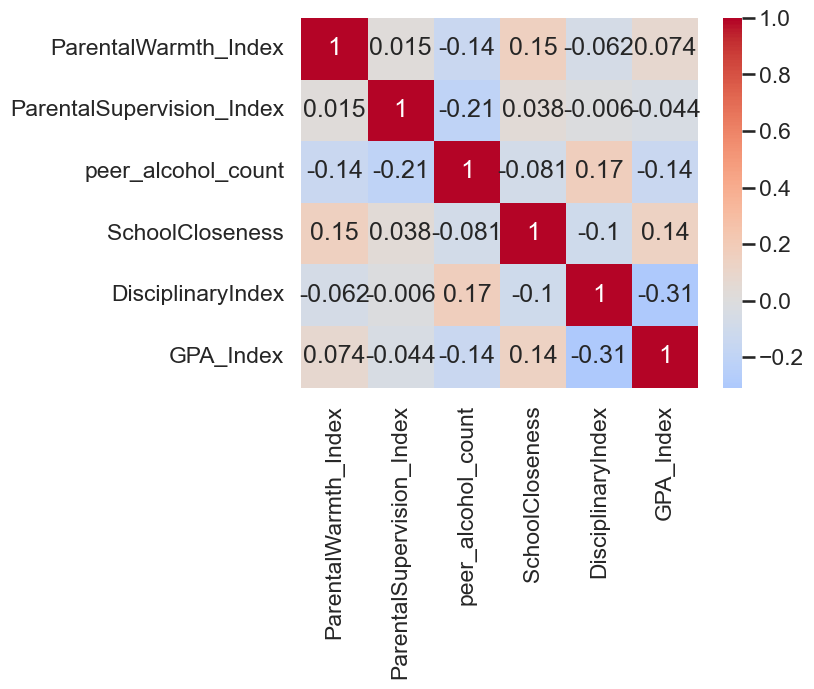

In [474]:
corr_vars = [
    'ParentalWarmth_Index', 'ParentalSupervision_Index',
    'peer_alcohol_count',
    'SchoolCloseness', 'DisciplinaryIndex', 'GPA_Index'
]

sns.heatmap(df1[corr_vars].corr(), annot=True, cmap='coolwarm', center=0)


The correlation structure shows three main clusters of influence. First, peer alcohol involvement is moderately associated with reduced parental supervision, reduced warmth, and greater disciplinary involvement, suggesting that peer dynamics are situated within broader behavioral and family contexts. Second, school closeness and GPA function as protective factors, each associated with fewer disciplinary issues and healthier peer environments. Third, parental warmth and supervision appear largely independent of these pathways, showing minimal correlation with other predictors. Overall, the variables most connected to future drinking tendencies, disciplinary problems, peer alcohol exposure, and academic performance, already show interlinked risk patterns in the correlation matrix, while parenting measures remain only weakly related.

## Personal & Psychological

In [344]:
import numpy as np
import pandas as pd

# can/t shake off blues despite help from family
df1['BluesInspiteOfHelp'] = pd.to_numeric(df1['H1FS3'], errors='coerce')

# Replace special codes (6, 8, 9 if any) with NaN
df1['BluesInspiteOfHelp'] = df1['BluesInspiteOfHelp'].replace({6: np.nan, 8: np.nan, 9: np.nan})

# Verify distribution
print(df1['BluesInspiteOfHelp'].value_counts(dropna=False).sort_index())


BluesInspiteOfHelp
0.0    3663
1.0    1030
2.0     302
3.0     107
NaN      12
Name: count, dtype: int64


In [345]:
# you feel less than others
df1['LessThanOthers'] = pd.to_numeric(df1['H1FS4'], errors='coerce')
df1['LessThanOthers'] = df1['LessThanOthers'].replace({6: np.nan, 8: np.nan, 9: np.nan})

# Reverse code (0–3 scale)
# Higher original = more self-worth → reverse to make higher = more depressed
df1['LessThanOthers'] = 3 - df1['LessThanOthers']


print("\nReversed:")
print(df1['LessThanOthers'].value_counts(dropna=False).sort_index())



Reversed:
LessThanOthers
0.0    1850
1.0    1637
2.0    1050
3.0     566
NaN      11
Name: count, dtype: int64


In [346]:
#when were you happy? 0 for always 3 for rarely
# Clean and recode H1FS11
df1['Unhappy'] = pd.to_numeric(df1['H1FS11'], errors='coerce')
df1['Unhappy'] = df1['Unhappy'].replace({6: np.nan, 8: np.nan, 9: np.nan})

# Reverse code: 0–3 → 3–0 (higher = more depressed)
df1['Unhappy'] = 3 - df1['Unhappy']


print("\nReversed:")
print(df1['Unhappy'].value_counts(dropna=False).sort_index())



Reversed:
Unhappy
0.0    1904
1.0    2130
2.0     944
3.0     127
NaN       9
Name: count, dtype: int64


In [347]:
#lonely
# Clean and recode H1FS13
df1['Lonely'] = pd.to_numeric(df1['H1FS13'], errors='coerce')
df1['Lonely'] = df1['Lonely'].replace({6: np.nan, 8: np.nan, 9: np.nan})

# Check distribution
print(df1['Lonely'].value_counts(dropna=False).sort_index())


Lonely
0.0    3280
1.0    1398
2.0     317
3.0     109
NaN      10
Name: count, dtype: int64


In [348]:
# People unfriendly to you
df1['UnfriendlyPeople'] = pd.to_numeric(df1['H1FS14'], errors='coerce')
df1['UnfriendlyPeople'] = df1['UnfriendlyPeople'].replace({6: np.nan, 8: np.nan, 9: np.nan})

# Check distribution
print(df1['UnfriendlyPeople'].value_counts(dropna=False).sort_index())


UnfriendlyPeople
0.0    3384
1.0    1452
2.0     210
3.0      60
NaN       8
Name: count, dtype: int64


In [349]:
# you feel it's hard to start things
df1['HardToStart'] = pd.to_numeric(df1['H1FS18'], errors='coerce')
df1['HardToStart'] = df1['HardToStart'].replace({6: np.nan, 8: np.nan, 9: np.nan})

# Check distribution
print(df1['HardToStart'].value_counts(dropna=False).sort_index())


HardToStart
0.0    2442
1.0    2225
2.0     380
3.0      58
NaN       9
Name: count, dtype: int64


In [350]:
# Ever felt life wasn't worth living?
df1['NotWorthLiving'] = pd.to_numeric(df1['H1FS19'], errors='coerce')
df1['NotWorthLiving'] = df1['NotWorthLiving'].replace({6: np.nan, 8: np.nan, 9: np.nan})

# Check distribution
print(df1['NotWorthLiving'].value_counts(dropna=False).sort_index())


NotWorthLiving
0.0    4525
1.0     417
2.0     118
3.0      44
NaN      10
Name: count, dtype: int64


In [14]:
#drinking averages for each variable
depression_vars = [
    'BluesInspiteOfHelp',   # Could not shake off the blues
    'LessThanOthers',     # Felt just as good as others (reversed)
    'Unhappy',    # Were happy (reversed)
    'Lonely',  # Felt lonely
    'UnfriendlyPeople',  # People unfriendly
    'HardToStart',  # Hard to get started
    'NotWorthLiving'   # Life not worth living
]

results = []

for var in depression_vars:
    temp = df1.dropna(subset=[var, dep])
    group_means = temp.groupby(var)[dep].mean()
    results.append(group_means)

# Combine results into a single DataFrame for easy comparison
mean_table = pd.concat(results, axis=1)
mean_table.columns = depression_vars

print(mean_table.round(2))


     BluesInspiteOfHelp  LessThanOthers  Unhappy  Lonely  UnfriendlyPeople  \
0.0                1.67            1.68     1.59    1.69              1.67   
1.0                1.69            1.76     1.77    1.69              1.79   
2.0                2.18            1.75     1.77    1.68              1.79   
3.0                1.53            1.55     1.68    2.49              1.76   

     HardToStart  NotWorthLiving  
0.0         1.72            1.66  
1.0         1.71            1.92  
2.0         1.54            2.03  
3.0         2.27            3.68  


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel

# -----------------------------
# Weighted Spearman function
# -----------------------------
def weighted_spearman(x, y, w):
    x_rank = rankdata(x)
    y_rank = rankdata(y)

    mx = np.average(x_rank, weights=w)
    my = np.average(y_rank, weights=w)

    cov = np.average((x_rank - mx) * (y_rank - my), weights=w)
    vx = np.average((x_rank - mx) ** 2, weights=w)
    vy = np.average((y_rank - my) ** 2, weights=w)

    return cov / np.sqrt(vx * vy)

# -----------------------------
# Depression variables
# -----------------------------
depression_vars = [
    'BluesInspiteOfHelp',
    'LessThanOthers',
    'Unhappy',
    'Lonely',
    'UnfriendlyPeople',
    'HardToStart',
    'NotWorthLiving'
]

rows = []

for v in depression_vars:
    temp = df1[[v, dep, 'Weight']].copy()

    # numeric safety
    temp[v] = pd.to_numeric(temp[v], errors='coerce')
    temp[dep] = pd.to_numeric(temp[dep], errors='coerce')
    temp['Weight'] = pd.to_numeric(temp['Weight'], errors='coerce')

    temp = temp.dropna(subset=[v, dep, 'Weight'])
    temp = temp[temp['Weight'] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    # --------
    # Weighted Spearman
    # --------
    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp['Weight'].to_numpy()
    )

    # --------
    # Ordinal logit
    # --------
    temp2 = df1[[v, dep]].copy()
    temp2[v] = pd.to_numeric(temp2[v], errors='coerce')
    temp2[dep] = pd.to_numeric(temp2[dep], errors='coerce')
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(y_ord, X, distr='logit').fit(
            method='bfgs', maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n = int(temp2.shape[0])
    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_dep = pd.DataFrame(rows).sort_values(
    "WeightedSpearman", ascending=False
)

print(results_dep.round(3))


             Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
6      NotWorthLiving             0.049  2208         0.259       1.295   
0  BluesInspiteOfHelp             0.021  2207         0.067       1.069   
5         HardToStart             0.010  2208        -0.027       0.974   
4    UnfriendlyPeople             0.007  2208         0.036       1.037   
2             Unhappy             0.005  2208         0.046       1.047   
3              Lonely             0.004  2207         0.043       1.044   
1      LessThanOthers            -0.050  2207        -0.041       0.960   

   Ordinal_p  
6      0.001  
0      0.222  
5      0.648  
4      0.581  
2      0.352  
3      0.441  
1      0.309  


Weighted Spearman correlations indicate weak population-level associations between depressive symptom items and marijuana use frequency. Ordinal logistic regression results similarly show no significant relationships for most depressive symptoms, including sadness, loneliness, and perceived social exclusion. However, the item capturing severe psychological distress, whether respondents felt that life was not worth living, exhibits a statistically significant association with marijuana use frequency (OR = 1.30, p = 0.001). This suggests that only extreme forms of emotional distress, rather than general depressive affect, are associated with higher marijuana use intensity in adulthood.

In [352]:
import numpy as np
import pandas as pd

# Your psychological variable names
psych_vars = [
    'BluesInspiteOfHelp', 
    'LessThanOthers', 
    'Unhappy', 
    'Lonely', 
    'UnfriendlyPeople', 
    'HardToStart', 
    'NotWorthLiving'
]

# Drop missing cases for alpha calculation
psych_df = df1[psych_vars].dropna()

# Compute Cronbach's alpha
k = len(psych_vars)
item_variances = psych_df.var(axis=0, ddof=1)
total_variance = psych_df.sum(axis=1).var(ddof=1)
cronbach_alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

print(f"Cronbach’s alpha for psychological variables: {cronbach_alpha:.3f}")


Cronbach’s alpha for psychological variables: 0.674


                    BluesInspiteOfHelp  LessThanOthers  Unhappy  Lonely  \
BluesInspiteOfHelp                1.00            0.20     0.33    0.46   
LessThanOthers                    0.20            1.00     0.35    0.18   
Unhappy                           0.33            0.35     1.00    0.30   
Lonely                            0.46            0.18     0.30    1.00   
UnfriendlyPeople                  0.20            0.13     0.14    0.27   
HardToStart                       0.24            0.09     0.16    0.26   
NotWorthLiving                    0.37            0.22     0.26    0.32   

                    UnfriendlyPeople  HardToStart  NotWorthLiving  
BluesInspiteOfHelp              0.20         0.24            0.37  
LessThanOthers                  0.13         0.09            0.22  
Unhappy                         0.14         0.16            0.26  
Lonely                          0.27         0.26            0.32  
UnfriendlyPeople                1.00         0.22          

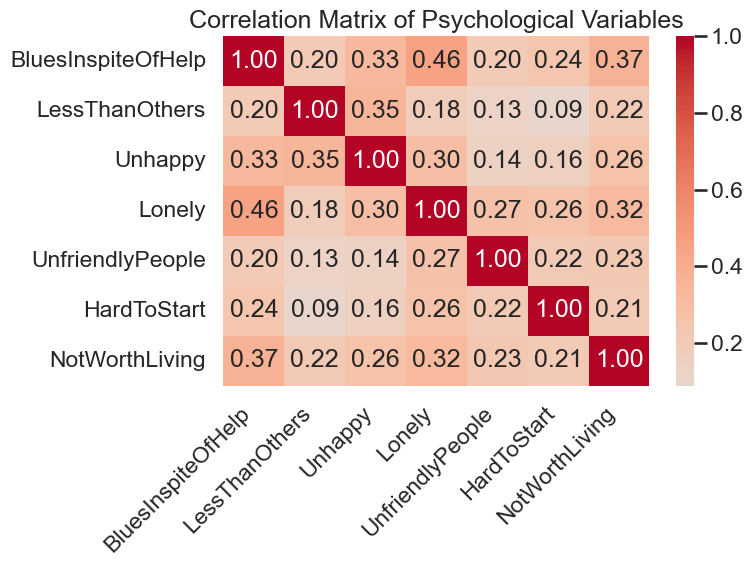

In [353]:
import seaborn as sns
import matplotlib.pyplot as plt

# Subset dataframe for psychological variables
psych_vars = [
    'BluesInspiteOfHelp', 
    'LessThanOthers', 
    'Unhappy', 
    'Lonely', 
    'UnfriendlyPeople', 
    'HardToStart', 
    'NotWorthLiving'
]

psych_corr = df1[psych_vars].corr()

# Display correlation matrix
print(psych_corr.round(2))

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(psych_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Matrix of Psychological Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [87]:
df1 = df1.rename(columns={
    "H1PF32": "ProudOfYourself_W1",
    "H1PF33": "LikeYourself_W1"
})


In [88]:
for v in ["ProudOfYourself_W1", "LikeYourself_W1"]:
    print(v, df1[v].unique())


ProudOfYourself_W1 [2 1 3 4 5 6 8]
LikeYourself_W1 [2 3 4 1 5 6 8]


In [89]:
df1[["ProudOfYourself_W1", "LikeYourself_W1"]] = \
    df1[["ProudOfYourself_W1", "LikeYourself_W1"]].replace([6,8], np.nan)

df1[["ProudOfYourself_W1", "LikeYourself_W1"]] = \
    df1[["ProudOfYourself_W1", "LikeYourself_W1"]].apply(pd.to_numeric, errors="coerce")


In [90]:
df1 = df1.rename(columns={
    "ProudOfYourself_W1": "ProudOfYourself_rev",
    "LikeYourself_W1": "LikeYourself_rev"
})

In [44]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel

# -----------------------------
# Weighted Spearman function
# -----------------------------
def weighted_spearman(x, y, w):
    x_rank = rankdata(x)
    y_rank = rankdata(y)

    mx = np.average(x_rank, weights=w)
    my = np.average(y_rank, weights=w)

    cov = np.average((x_rank - mx) * (y_rank - my), weights=w)
    vx = np.average((x_rank - mx) ** 2, weights=w)
    vy = np.average((y_rank - my) ** 2, weights=w)

    return cov / np.sqrt(vx * vy)

# -----------------------------
# Self-esteem variables
# -----------------------------
esteem_vars = [
    "ProudOfYourself_rev",
    "LikeYourself_rev"
]

rows = []

for v in esteem_vars:
    temp = df1[[v, dep, "Weight"]].copy()

    # numeric safety
    temp[v] = pd.to_numeric(temp[v], errors="coerce")
    temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    # --------
    # Weighted Spearman (descriptive)
    # --------
    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # --------
    # Ordinal logit (inferential)
    # --------
    temp2 = df1[[v, dep]].copy()
    temp2[v] = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(y_ord, X, distr="logit").fit(
            method="bfgs", maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n = int(temp2.shape[0])
    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_esteem = pd.DataFrame(rows).sort_values(
    "WeightedSpearman", ascending=False
)

print(results_esteem.round(3))


              Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
0  ProudOfYourself_rev             0.019  2206         0.033       1.034   
1     LikeYourself_rev            -0.016  2208        -0.036       0.964   

   Ordinal_p  
0      0.532  
1      0.380  


In [94]:
df1 = df1.rename(columns={
    "H1FS5": "TroubleConcentrating_W1",
    "H1FS6": "FeelingDepressed_W1",
    "H1FS7": "TooTiredToDoThings_W1"
})


In [17]:
fs_vars = [
    "TroubleConcentrating_W1",
    "FeelingDepressed_W1",
    "TooTiredToDoThings_W1"
]

for v in fs_vars:
    print(v, df1[v].unique())


TroubleConcentrating_W1 [ 3.  0.  1.  2. nan]
FeelingDepressed_W1 [ 0.  1.  2.  3. nan]
TooTiredToDoThings_W1 [ 1.  0.  2.  3. nan]


In [96]:
# ensure numeric
df1[fs_vars] = df1[fs_vars].apply(pd.to_numeric, errors='coerce')

df1[fs_vars] = df1[fs_vars].replace([6, 8], np.nan)



In [18]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel



# -----------------------------
# Loop over fs_vars
# -----------------------------
rows = []

for v in fs_vars:
    temp = df1[[v, dep, "Weight"]].copy()

    # numeric safety
    temp[v] = pd.to_numeric(temp[v], errors="coerce")
    temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    # --------
    # Weighted Spearman (descriptive)
    # --------
    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # --------
    # Ordinal logit (inferential)
    # --------
    temp2 = df1[[v, dep]].copy()
    temp2[v] = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(y_ord, X, distr="logit").fit(
            method="bfgs", maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n = int(temp2.shape[0])
    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_fs = pd.DataFrame(rows).sort_values(
    "WeightedSpearman", ascending=False
)

print(results_fs.round(3))


                  Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
0  TroubleConcentrating_W1             0.034  2207         0.102       1.107   
1      FeelingDepressed_W1            -0.004  2207         0.021       1.021   
2    TooTiredToDoThings_W1            -0.022  2208        -0.036       0.964   

   Ordinal_p  
0      0.035  
1      0.686  
2      0.501  


Financial and stress-related variables exhibit weak associations with marijuana use frequency. While trouble concentrating is associated with slightly higher odds of more frequent use (OR = 1.11, p = 0.035), other measures of emotional distress and fatigue show no significant relationships. Overall, these findings suggest that functional impairment rather than general mood or stress is more relevant for marijuana use intensity.

In [98]:
df1 = df1.rename(columns={"H1SE4": "SelfRatedIntelligence_W1"})


In [99]:
print(df1["SelfRatedIntelligence_W1"].unique())


[ 3  2  5  4  6  1 98 96]


In [100]:
df1["SelfRatedIntelligence_W1"] = pd.to_numeric(df1["SelfRatedIntelligence_W1"], errors="coerce")
df1["SelfRatedIntelligence_W1"] = df1["SelfRatedIntelligence_W1"].replace([96,98], np.nan)



In [19]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel


# -----------------------------
# Variable
# -----------------------------
v = "SelfRatedIntelligence_W1"

# ===== Weighted Spearman (descriptive) =====
temp = df1[[v, dep, "Weight"]].copy()

# numeric safety
temp[v] = pd.to_numeric(temp[v], errors="coerce")
temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

temp = temp.dropna(subset=[v, dep, "Weight"])
temp = temp[temp["Weight"] > 0]

rho = weighted_spearman(
    temp[v].to_numpy(),
    temp[dep].to_numpy(),
    temp["Weight"].to_numpy()
)

print(f"Weighted Spearman correlation ({v} vs {dep}): {rho:.3f}")

# ===== Ordinal logistic regression (inferential) =====
temp2 = df1[[v, dep]].copy()
temp2[v] = pd.to_numeric(temp2[v], errors="coerce")
temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
temp2 = temp2.dropna(subset=[v, dep])

y_ord = temp2[dep].astype(int)
X = temp2[[v]]

model = OrderedModel(y_ord, X, distr="logit")
res = model.fit(method="bfgs", maxiter=1000, disp=False)

print(res.summary())
print("OR:", np.exp(res.params[v]))


Weighted Spearman correlation (SelfRatedIntelligence_W1 vs DaysMarijuanaPast12M_W4): 0.001
                                OrderedModel Results                               
Dep. Variable:     DaysMarijuanaPast12M_W4   Log-Likelihood:                -3426.8
Model:                        OrderedModel   AIC:                             6868.
Method:                 Maximum Likelihood   BIC:                             6907.
Date:                     Fri, 09 Jan 2026                                         
Time:                             16:25:08                                         
No. Observations:                     2206                                         
Df Residuals:                         2199                                         
Df Model:                                1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [102]:
df1 = df1.rename(columns={
    "H1PR1": "AdultCare_W1",
    "H1PR2": "TeacherCare_W1",
    "H1PR3": "ParentCare_W1",
    "H1PR4": "FriendCare_W1",
    "H1PR6": "WantLeaveHome_W1"
})


In [103]:
vars_pr = [
    "AdultCare_W1",
    "TeacherCare_W1",
    "ParentCare_W1",
    "FriendCare_W1",
    "WantLeaveHome_W1"
]
df1[vars_pr] = df1[vars_pr].apply(pd.to_numeric, errors='coerce')
clean_codes = [6, 96, 98]



df1[vars_pr] = df1[vars_pr].replace(clean_codes, np.nan)




In [20]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel



# -----------------------------
# Variables
# -----------------------------
care_vars = [
    "AdultCare_W1",
    "TeacherCare_W1",
    "ParentCare_W1",
    "FriendCare_W1",
    "WantLeaveHome_W1"
]

rows = []

for v in care_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v] = pd.to_numeric(temp[v], errors="coerce")
    temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordinal logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v] = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(y_ord, X, distr="logit").fit(
            method="bfgs", maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n = int(temp2.shape[0])
    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_care = pd.DataFrame(rows).sort_values(
    "WeightedSpearman", ascending=False
)

print(results_care.round(3))


           Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
4  WantLeaveHome_W1             0.025  2179         0.056       1.057   
2     ParentCare_W1            -0.006  2207        -0.148       0.863   
0      AdultCare_W1            -0.007  2204        -0.086       0.917   
3     FriendCare_W1            -0.059  2206        -0.161       0.852   
1    TeacherCare_W1            -0.059  2190        -0.126       0.882   

   Ordinal_p  
4      0.075  
2      0.034  
0      0.073  
3      0.003  
1      0.002  


Weighted Spearman correlations indicate weak population-level associations between perceived care variables and marijuana use frequency. However, ordinal logistic regression results reveal that higher perceived care from parents, teachers, and friends is associated with significantly lower odds of being in more frequent marijuana-use categories. In contrast, dissatisfaction with the home environment, as captured by a desire to leave home, is associated with slightly higher odds of frequent use. These findings suggest that supportive social relationships, particularly within school and peer contexts, play a modest but protective role in shaping marijuana use intensity in adulthood.

## Motivations to Engage in Risky Sexual Behaviors

In [22]:
rename_map = {
    'H1MO1': 'FriendsRespect_Sex',
    'H1MO3': 'Rev_FeelGuilty_Sex',
    'H1MO4': 'Rev_UpsetMother_Sex',
    'H1MO5': 'Pleasure_Sex',
    'H1MO6': 'Relax_Sex',
    'H1MO7': 'Attractive_Sex',
    'H1MO8': 'LessLonely_Sex'
   
}


# 2️⃣ Clean invalid responses (6–9 → NaN)
motivation_vars = list(rename_map.values())

In [355]:

# Convert to numeric safely
for var in motivation_vars:
    df1[var] = pd.to_numeric(df1[var], errors='coerce')


In [356]:
for v in  motivation_vars:
    df1[v] = pd.to_numeric(df1[v], errors='coerce')
    df1.loc[df1[v].isin([6,7,8,9]), v] = np.nan
    reverse_vars = ['FriendsRespect_Sex','Pleasure_Sex','Attractive_Sex','LessLonely_Sex','Relax_Sex']
for v in reverse_vars:
    df1[v] = 6 - df1[v]



In [23]:
# 4️⃣ Display average TotalDrinks by response level for each variable
print("Average Smoking by Response Level for Each Motivation Variable:\n")
for v in motivation_vars:
    avg_table = (
        df1.groupby(v, dropna=True)[dep]
           .mean()
           .round(2)
    )
    print(f"\n{v}")
    print(avg_table)


Average Smoking by Response Level for Each Motivation Variable:


FriendsRespect_Sex
FriendsRespect_Sex
1.0    1.21
2.0    1.44
3.0    1.87
4.0    2.06
5.0    1.55
Name: DaysMarijuanaPast12M_W4, dtype: float64

Rev_FeelGuilty_Sex
Rev_FeelGuilty_Sex
1.0    1.29
2.0    1.41
3.0    1.81
4.0    1.62
5.0    1.80
Name: DaysMarijuanaPast12M_W4, dtype: float64

Rev_UpsetMother_Sex
Rev_UpsetMother_Sex
1.0    1.38
2.0    1.66
3.0    1.57
4.0    1.80
5.0    2.51
Name: DaysMarijuanaPast12M_W4, dtype: float64

Pleasure_Sex
Pleasure_Sex
1.0    0.79
2.0    2.06
3.0    1.61
4.0    1.63
5.0    1.64
Name: DaysMarijuanaPast12M_W4, dtype: float64

Relax_Sex
Relax_Sex
1.0    1.07
2.0    1.35
3.0    1.58
4.0    1.86
5.0    1.75
Name: DaysMarijuanaPast12M_W4, dtype: float64

Attractive_Sex
Attractive_Sex
1.0    1.36
2.0    1.58
3.0    1.72
4.0    1.87
5.0    1.75
Name: DaysMarijuanaPast12M_W4, dtype: float64

LessLonely_Sex
LessLonely_Sex
1.0    1.42
2.0    1.46
3.0    1.77
4.0    1.82
5.0    1.98
Name: Days

In [24]:

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from statsmodels.miscmodels.ordinal_model import OrderedModel


rows = []

for v in motivation_vars:
    # ===== Weighted Spearman (descriptive) =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v] = pd.to_numeric(temp[v], errors="coerce")
    temp[dep] = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordinal logit (inferential) =====
    temp2 = df1[[v, dep]].copy()
    temp2[v] = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(y_ord, X, distr="logit").fit(
            method="bfgs", maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n = int(temp2.shape[0])
    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_motivation = pd.DataFrame(rows).sort_values(
    "WeightedSpearman", ascending=False
)

print(results_motivation.round(3))


              Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
0   FriendsRespect_Sex             0.140  1437         0.197       1.218   
4            Relax_Sex             0.084  1420         0.141       1.152   
5       Attractive_Sex             0.077  1431         0.117       1.124   
6       LessLonely_Sex             0.065  1431         0.108       1.114   
1   Rev_FeelGuilty_Sex             0.051  1434         0.084       1.088   
2  Rev_UpsetMother_Sex             0.047  1324         0.120       1.127   
3         Pleasure_Sex             0.010  1426        -0.001       0.999   

   Ordinal_p  
0      0.000  
4      0.012  
5      0.032  
6      0.031  
1      0.056  
2      0.010  
3      0.981  


Although several sex-related emotional and social variables were statistically significant predictors, effect sizes were uniformly small. The strongest association was observed for perceived respect from friends (OR = 1.22), while pleasure during sex showed no association with the outcome. Overall, findings suggest that social and emotional dimensions of sexual experience, rather than pleasure, are more relevant correlates.

## Delinqueny Behavior and Drinking

In [107]:
'Delinquency_Index' in df1

True

In [26]:
import pandas as pd

# Selected delinquency variables related to drinking
del_vars = {
    'H1DS5': 'Fight_Serious',
    'H1DS6': 'InjuredSomeone',
    'H1DS8': 'DroveWithoutPermission',
    'H1DS11': 'WeaponUse_Threat',
    'H1DS12': 'SoldDrugs',
    'H1DS14': 'GroupFight',
    'H1DS15': 'PublicRowdy',
    'H1DS3': 'LiedToParents'  # optional
}
df1[list(del_vars.values())] = df1[list(del_vars.values())].replace({6: np.nan, 8: np.nan, 9: np.nan})
df_delinquency = df1[list(del_vars.values())]

# Descriptive counts and proportions for each
for col in df_delinquency.columns:
    print(f"\n{col}:")
    print(df_delinquency[col].value_counts(normalize=False).sort_index())
    



Fight_Serious:
Fight_Serious
0.0    3481
1.0    1162
2.0     239
3.0     203
Name: count, dtype: int64

InjuredSomeone:
InjuredSomeone
0.0    4189
1.0     699
2.0     111
3.0      81
Name: count, dtype: int64

DroveWithoutPermission:
DroveWithoutPermission
0.0    4598
1.0     367
2.0      65
3.0      57
Name: count, dtype: int64

WeaponUse_Threat:
WeaponUse_Threat
0.0    4882
1.0     159
2.0      28
3.0      22
Name: count, dtype: int64

SoldDrugs:
SoldDrugs
0.0    4735
1.0     187
2.0      49
3.0     115
Name: count, dtype: int64

GroupFight:
GroupFight
0.0    4140
1.0     742
2.0     109
3.0      98
Name: count, dtype: int64

PublicRowdy:
PublicRowdy
0.0    2634
1.0    1682
2.0     396
3.0     375
Name: count, dtype: int64

LiedToParents:
LiedToParents
0.0    2400
1.0    1481
2.0     510
3.0     686
Name: count, dtype: int64


In [112]:
# Standardize
scaler = StandardScaler()
df1[[v + "_Z" for v in del_vars.values()]] = scaler.fit_transform(df1[del_vars.values()])

# Create delinquency index = mean of Z-scores
df1["Delinquency_Index"] = df1[[v + "_Z" for v in del_vars.values()]].mean(axis=1)

count    5093.000000
mean        0.000530
std         0.593047
min        -0.497968
25%        -0.351844
50%        -0.196015
75%         0.173950
max         4.914413
Name: Delinquency_Index, dtype: float64


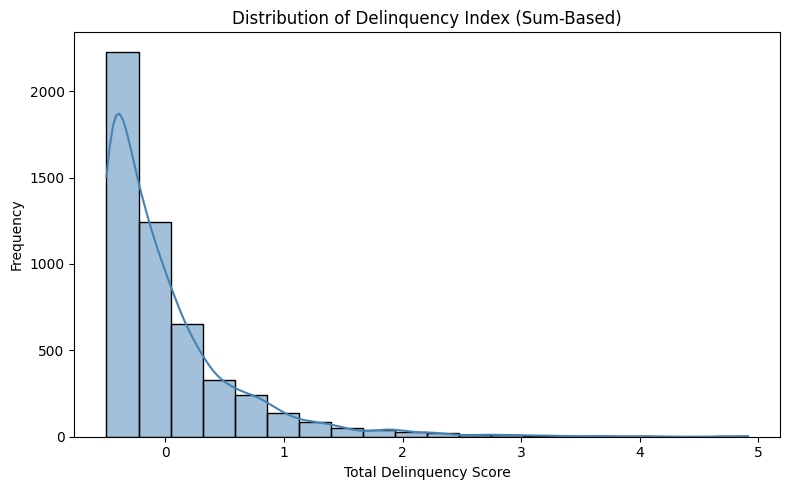

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df1['Delinquency_Index'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df1['Delinquency_Index'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Delinquency Index (Sum-Based)')
plt.xlabel('Total Delinquency Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [28]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

rows = []

for v in df_delinquency.columns:   # <-- your predictor list
    # ===== Weighted Spearman (descriptive) =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]      = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]    = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordinal logit (inferential) =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_delinquency = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_delinquency.round(3))



                 Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
4               SoldDrugs             0.101  2200         0.263       1.300   
0           Fight_Serious             0.078  2199         0.137       1.147   
5              GroupFight             0.062  2200         0.174       1.190   
2  DroveWithoutPermission             0.054  2199         0.231       1.260   
1          InjuredSomeone             0.054  2194         0.118       1.125   
3        WeaponUse_Threat             0.033  2202         0.221       1.247   
6             PublicRowdy             0.026  2200         0.064       1.066   
7           LiedToParents             0.025  2193         0.042       1.042   

   Ordinal_p  
4      0.000  
0      0.004  
5      0.005  
2      0.002  
1      0.059  
3      0.050  
6      0.115  
7      0.238  


Several delinquency indicators were significantly associated with marijuana smoking. The strongest effects were observed for drug-selling behavior (OR = 1.30), unauthorized driving (OR = 1.26), and weapon-related threats (OR = 1.25). These findings suggest that marijuana use is more strongly linked to rule-breaking and peer-based delinquent contexts than to severe interpersonal violence or generalized antisocial behavior.

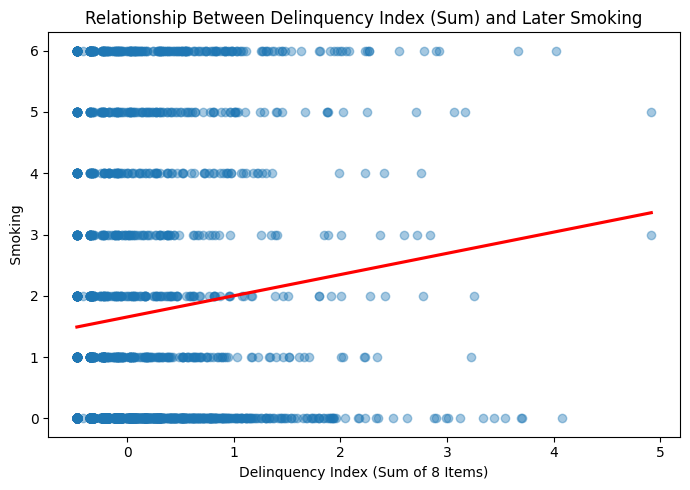

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.regplot(
    data=df1,
    x='Delinquency_Index',
    y=dep,
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'},
    ci=None
)
plt.title('Relationship Between Delinquency Index (Sum) and Later Smoking')
plt.xlabel('Delinquency Index (Sum of 8 Items)')
plt.ylabel(' Smoking ')
plt.tight_layout()
plt.show()


## Sports

In [35]:
# Define variables from S44A18 to S44A29
sports_vars = [f'S44A{i}' for i in range(18, 30)]

# Quick preview
df1[sports_vars].head()


,S44A18,S44A19,S44A20,S44A21,S44A22,S44A23,S44A24,S44A25,S44A26,S44A27,S44A28,S44A29
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [366]:
for var in sports_vars:
    print(f"\n{var} unique values:")
    print(df1[var].unique())



S44A18 unique values:
['0' ' ' '1']

S44A19 unique values:
['0' ' ' '1']

S44A20 unique values:
['0' ' ' '1']

S44A21 unique values:
['0' ' ' '1']

S44A22 unique values:
['0' ' ' '1']

S44A23 unique values:
['0' ' ' '1']

S44A24 unique values:
['0' ' ' '1']

S44A25 unique values:
['0' ' ' '1']

S44A26 unique values:
['0' ' ' '1']

S44A27 unique values:
['0' ' ' '1']

S44A28 unique values:
['0' ' ' '1']

S44A29 unique values:
['0' ' ' '1']


In [367]:
# Convert to numeric (turns ".", blanks, etc. into NaN)
df1[sports_vars] = df1[sports_vars].apply(pd.to_numeric, errors='coerce')
# Univariate exploration
for var in sports_vars:
    print(f"\n--- {var} ---")
    counts = df1[var].value_counts(dropna=False)
    proportions = (counts / len(df1) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percent': proportions}))


--- S44A18 ---
        Count  Percent
S44A18                
0.0      3057    59.78
NaN      1318    25.77
1.0       739    14.45

--- S44A19 ---
        Count  Percent
S44A19                
0.0      2891    56.53
NaN      1318    25.77
1.0       905    17.70

--- S44A20 ---
        Count  Percent
S44A20                
0.0      3754    73.41
NaN      1318    25.77
1.0        42     0.82

--- S44A21 ---
        Count  Percent
S44A21                
0.0      3286    64.25
NaN      1318    25.77
1.0       510     9.97

--- S44A22 ---
        Count  Percent
S44A22                
0.0      3736    73.05
NaN      1318    25.77
1.0        60     1.17

--- S44A23 ---
        Count  Percent
S44A23                
0.0      3502    68.48
NaN      1318    25.77
1.0       294     5.75

--- S44A24 ---
        Count  Percent
S44A24                
0.0      3591    70.22
NaN      1318    25.77
1.0       205     4.01

--- S44A25 ---
        Count  Percent
S44A25                
0.0      3617    70.7

In [368]:
df1['SportsParticipation_Index'] = df1[sports_vars].sum(axis=1, skipna=True)


count    5114.000000
mean        0.836918
std         1.290716
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        12.000000
Name: SportsParticipation_Index, dtype: float64


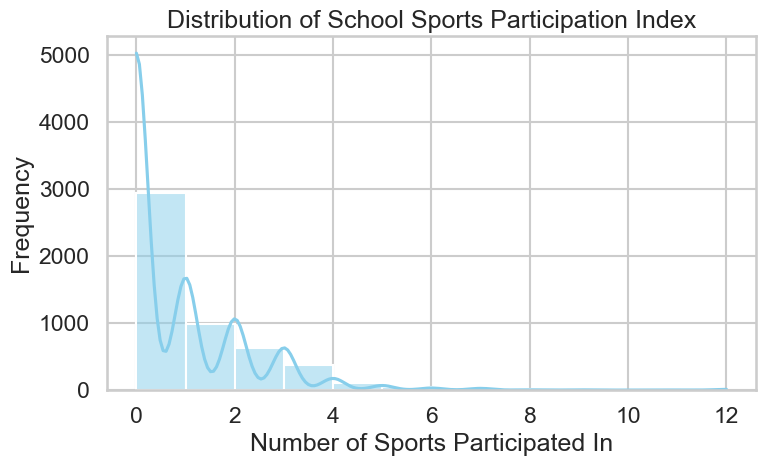

In [369]:
print(df1['SportsParticipation_Index'].describe())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df1['SportsParticipation_Index'], bins=range(0, len(sports_vars)+1), kde=True, color='skyblue')
plt.title('Distribution of School Sports Participation Index')
plt.xlabel('Number of Sports Participated In')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [33]:
avg_marsmoking_by_sports = (
    df1.groupby('SportsParticipation_Index')[dep]
    .mean()
    .reset_index()
    .rename(columns={'MarijuanaSmoking': dep})
)

print(avg_marsmoking_by_sports)


    SportsParticipation_Index  DaysMarijuanaPast12M_W4
0                         0.0                 1.744817
1                         1.0                 1.598608
2                         2.0                 1.684211
3                         3.0                 1.540698
4                         4.0                 2.232558
5                         5.0                 1.850000
6                         6.0                 1.777778
7                         7.0                 2.142857
8                         8.0                 2.500000
9                         9.0                 6.000000
10                       11.0                 0.000000
11                       12.0                 2.000000


In [36]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

rows = []

for v in sports_vars:   # <-- list of sports participation variables
    # ===== Weighted Spearman (descriptive) =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]       = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]     = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordinal logit (inferential) =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_sports = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_sports.round(3))


   Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  Ordinal_p
0    S44A18             0.058  1604         0.259       1.295      0.023
10   S44A28             0.033  1604         0.310       1.363      0.141
1    S44A19             0.021  1604         0.095       1.100      0.368
3    S44A21             0.015  1604         0.140       1.150      0.283
7    S44A25             0.012  1604         0.004       1.004      0.985
6    S44A24             0.007  1604        -0.027       0.973      0.889
5    S44A23            -0.004  1604         0.066       1.069      0.679
9    S44A27            -0.006  1604         0.029       1.029      0.863
2    S44A20            -0.010  1604         0.013       1.013      0.973
4    S44A22            -0.028  1604        -0.242       0.785      0.463
11   S44A29            -0.032  1604         0.025       1.025      0.869
8    S44A26            -0.067  1604        -0.185       0.831      0.185


Across sports participation variables, no consistent associations with drinking were observed. Participation in baseball was the only sport significantly associated with higher drinking levels (OR = 1.30, p = 0.023), suggesting that specific team-based social contexts, rather than sports participation per se, may be relevant.

In [372]:
df1['SportsParticipation_Index'].value_counts().sort_index()


SportsParticipation_Index
0.0     2950
1.0      984
2.0      624
3.0      370
4.0      102
5.0       40
6.0       18
7.0       15
8.0        2
9.0        2
11.0       1
12.0       6
Name: count, dtype: int64

## Drinking and Smoking in Youth

In [373]:
import pandas as pd
import numpy as np

# All variables in order
to_vars = ['H1TO1', 'H1TO3', 'H1TO4', 'H1TO5', 'H1TO7', 'H1TO13', 'H1TO14', 'H1TO15', 'H1TO16']

# Convert all to numeric
df1[to_vars] = df1[to_vars].apply(pd.to_numeric, errors='coerce')

# Replace 6–9 only for H1TO1, H1TO3, H1TO13
df1[['H1TO1', 'H1TO3', 'H1TO13']] = df1[['H1TO1', 'H1TO3', 'H1TO13']].replace({6: np.nan, 7: np.nan, 8: np.nan, 9: np.nan})

# Replace 96 and above for the remaining variables
for var in to_vars:
    df1[var] = df1[var].mask(df1[var] >= 96, np.nan)


In [374]:
rename_map = {
    'H1TO1': 'EverTried_Cigarette',
    'H1TO3': 'EverSmoked_Regularly',
    'H1TO4': 'Age_StartedSmoking',
    'H1TO5': 'Days_SmokedPast30',
    'H1TO7': 'CigsPerDay_Past30',
    'H1TO13': 'DrinkWithoutAdults',
    'H1TO14': 'Age_FirstDrinkNoAdults',
    'H1TO15': 'DrinkFrequency_Past12mo',
    'H1TO16': 'DrinksPerOccasion_Past12mo'
}

df1 = df1.rename(columns=rename_map)


In [375]:
flip_map = {1: 7, 2: 6, 3: 5, 4: 4, 5: 3, 6: 2, 7: 1}
df1['DrinkFrequency_Past12mo'] = df1['DrinkFrequency_Past12mo'].replace(flip_map)

In [376]:
all_vars = list(rename_map.values())

for var in all_vars:
    print(f"\n--- {var} ---")
    counts = df1[var].value_counts(dropna=False).sort_index()
    proportions = (counts / len(df1) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percent': proportions}))



--- EverTried_Cigarette ---
                     Count  Percent
EverTried_Cigarette                
0.0                   2244    43.88
1.0                   2845    55.63
NaN                     25     0.49

--- EverSmoked_Regularly ---
                      Count  Percent
EverSmoked_Regularly                
0.0                    1167    22.82
1.0                    1014    19.83
NaN                    2933    57.35

--- Age_StartedSmoking ---
                    Count  Percent
Age_StartedSmoking                
0.0                     5     0.10
1.0                     2     0.04
5.0                     1     0.02
6.0                     4     0.08
7.0                     4     0.08
8.0                    13     0.25
9.0                     9     0.18
10.0                   34     0.66
11.0                   49     0.96
12.0                  127     2.48
13.0                  175     3.42
14.0                  195     3.81
15.0                  158     3.09
16.0                  1

In [37]:
substance_vars = [
    'EverTried_Cigarette',
    'EverSmoked_Regularly',
    'Age_StartedSmoking',
    'Days_SmokedPast30',
    'CigsPerDay_Past30',
    'DrinkWithoutAdults',
    'Age_FirstDrinkNoAdults',
    'DrinkFrequency_Past12mo',
    'DrinksPerOccasion_Past12mo'
]
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

rows = []

for v in substance_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]       = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]     = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_substances = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_substances.round(3))


                     Variable  WeightedSpearman     N  Ordinal_beta  \
7     DrinkFrequency_Past12mo             0.057  1513         0.054   
0         EverTried_Cigarette             0.045  2202         0.098   
8  DrinksPerOccasion_Past12mo             0.030  1307         0.017   
1        EverSmoked_Regularly            -0.003  1294        -0.039   
3           Days_SmokedPast30            -0.008  1284        -0.002   
5          DrinkWithoutAdults            -0.010  1519        -0.115   
4           CigsPerDay_Past30            -0.016   834         0.003   
2          Age_StartedSmoking            -0.058   672        -0.020   
6      Age_FirstDrinkNoAdults            -0.106  1155        -0.076   

   Ordinal_OR  Ordinal_p  
7       1.056      0.097  
0       1.102      0.261  
8       1.017      0.035  
1       0.962      0.708  
3       0.998      0.578  
5       0.892      0.321  
4       1.003      0.707  
2       0.980      0.519  
6       0.926      0.001  


Among cigarette and alcohol indicators, only the age at first unsupervised alcohol use was robustly associated with marijuana smoking, suggesting that early exposure in unsupervised contexts, rather than substance use intensity, plays a key role.

In [38]:
# ================================
# 1) Define skip/missing codes
# ================================
skip_codes = [6, 8, 9]

# ================================
# 2) Peer Cigarette Use (H1TO9)
# ================================
df1['PeerCig_Count'] = pd.to_numeric(df1['H1TO9'], errors='coerce')

# Convert skip codes → NaN
df1['PeerCig_Count'] = df1['PeerCig_Count'].replace(skip_codes, np.nan)

# Binary: any friend smokes
df1['PeerCig_Any'] = (df1['PeerCig_Count'] >= 1).astype(float)

# ================================
# 3) Peer Marijuana Use (H1TO33)
# ================================
df1['PeerWeed_Count'] = pd.to_numeric(df1['H1TO33'], errors='coerce')
df1['PeerWeed_Count'] = df1['PeerWeed_Count'].replace(skip_codes, np.nan)

df1['PeerWeed_Any'] = (df1['PeerWeed_Count'] >= 1).astype(float)

# ================================
# 4) Inspect Distributions
# ================================
print("\nPeer Cigarette Count Distribution:")
print(df1['PeerCig_Count'].value_counts(dropna=False))

print("\nPeer Marijuana Count Distribution:")
print(df1['PeerWeed_Count'].value_counts(dropna=False))

peer_vars = [
    'PeerCig_Count',
    'PeerCig_Any',
    'PeerWeed_Count',
    'PeerWeed_Any'
]
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

rows = []

for v in peer_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]       = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]     = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_peers = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_peers.round(3))




Peer Cigarette Count Distribution:
PeerCig_Count
0.0    2802
1.0    1010
3.0     614
2.0     600
NaN      88
Name: count, dtype: int64

Peer Marijuana Count Distribution:
PeerWeed_Count
0.0    3362
1.0     809
3.0     432
2.0     411
NaN     100
Name: count, dtype: int64
         Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  Ordinal_p
2  PeerWeed_Count             0.095  2171         0.127       1.136      0.001
3    PeerWeed_Any             0.069  2210         0.158       1.171      0.046
0   PeerCig_Count             0.064  2187         0.063       1.065      0.073
1     PeerCig_Any             0.034  2210         0.044       1.045      0.582


In [39]:
import pandas as pd
import numpy as np

# ------------------------------
# 1. Import raw variables from df
# ------------------------------

df1['Age_FirstMarijuana'] = pd.to_numeric(df1['H1TO30'], errors='coerce')
df1['Lifetime_Marijuana'] = pd.to_numeric(df1['H1TO31'], errors='coerce')
df1['Age_FirstCocaine'] = pd.to_numeric(df1['H1TO34'], errors='coerce')
df1['Lifetime_Cocaine'] = pd.to_numeric(df1['H1TO35'], errors='coerce')


# ------------------------------
# 2. Clean invalid codes → NaN
# ------------------------------


# H1TO30: age first marijuana
# Valid: 0–10 (0 means never used)
df1['Age_FirstMarijuana'] = df1['Age_FirstMarijuana'].replace({
    96: np.nan, 97: np.nan, 98: np.nan, 99: np.nan
})
df1['Age_FirstCocaine'] = df1['Age_FirstCocaine'].replace({
    96: np.nan, 97: np.nan, 98: np.nan, 99: np.nan
})
# H1TO31: lifetime marijuana use
# Valid: 1–900
df1['Lifetime_Marijuana'] = df1['Lifetime_Marijuana'].replace({
    996: np.nan, 997: np.nan, 998: np.nan, 999: np.nan
})
df1['Lifetime_Cocaine'] = df1['Lifetime_Cocaine'].replace({
    996: np.nan, 997: np.nan, 998: np.nan, 999: np.nan
})

# ------------------------------
# 3. Quick distributions
# ------------------------------

print("Age First Marijuana Use:")
print(df1['Age_FirstMarijuana'].value_counts(dropna=False).head(5), "\n")
print("Age First Cocaine Use:")
print(df1['Age_FirstCocaine'].value_counts(dropna=False).head(5), "\n")
print("Lifetime Marijuana Use:")
print(df1['Lifetime_Marijuana'].describe(), "\n")
print("Lifetime Cocaine Use:")
print(df1['Lifetime_Cocaine'].describe(), "\n")

# ------------------------------
# 4. Correlations with future drinking
# ------------------------------
vars_to_check = ['PeerCig_Count','PeerWeed_Count', 'Age_FirstMarijuana', 'Lifetime_Marijuana','Age_FirstCocaine', 'Lifetime_Cocaine']

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

rows = []

for v in vars_to_check:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]       = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]     = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_future = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_future.round(3))




Age First Marijuana Use:
Age_FirstMarijuana
0.0     3723
14.0     287
15.0     251
16.0     236
13.0     189
Name: count, dtype: int64 

Age First Cocaine Use:
Age_FirstCocaine
0.0     4889
NaN       61
16.0      31
15.0      27
17.0      26
Name: count, dtype: int64 

Lifetime Marijuana Use:
count    1244.000000
mean       39.360932
std       100.124247
min         1.000000
25%         2.000000
50%         7.500000
75%        25.000000
max       900.000000
Name: Lifetime_Marijuana, dtype: float64 

Lifetime Cocaine Use:
count    157.000000
mean      13.636943
std       62.822109
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max      700.000000
Name: Lifetime_Cocaine, dtype: float64 

             Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
3  Lifetime_Marijuana             0.112   884         0.002       1.002   
5    Lifetime_Cocaine             0.107   112         0.001       1.001   
1      PeerWeed_Count             0.095  2171  

In [40]:
import numpy as np
import pandas as pd

# Create numeric version
df1['AlcoholAvailable_Home'] = pd.to_numeric(df1['H1TO51'], errors='coerce')
df1['DrugsAvailable_Home'] = pd.to_numeric(df1['H1TO52'], errors='coerce')
df1['GunAvailable_Home'] = pd.to_numeric(df1['H1TO53'], errors='coerce')
# Replace invalid codes with NaN
df1['AlcoholAvailable_Home'] = df1['AlcoholAvailable_Home'].replace({
    6: np.nan,
    8: np.nan,
    9: np.nan
})
df1['DrugsAvailable_Home'] = df1['DrugsAvailable_Home'].replace({
    6: np.nan,
    8: np.nan,
    9: np.nan
})
df1['GunAvailable_Home'] = df1['GunAvailable_Home'].replace({
    6: np.nan,
    8: np.nan,
    9: np.nan
})
# Show distribution
print("Alcohol Available at Home (cleaned):")
print(df1['AlcoholAvailable_Home'].value_counts(dropna=False))
print()
print("Drugs Available at Home (cleaned):")
print(df1['DrugsAvailable_Home'].value_counts(dropna=False))
print()
print("Guns Available at Home (cleaned):")
print(df1['GunAvailable_Home'].value_counts(dropna=False))
print()

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

home_vars = ['AlcoholAvailable_Home', 'DrugsAvailable_Home', 'GunAvailable_Home']
rows = []

for v in home_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(y_ord, X, distr="logit").fit(
            method="bfgs", maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])
    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_home = pd.DataFrame(rows).sort_values("WeightedSpearman", ascending=False)
print(results_home.round(3))


Alcohol Available at Home (cleaned):
AlcoholAvailable_Home
0.0    3611
1.0    1473
NaN      30
Name: count, dtype: int64

Drugs Available at Home (cleaned):
DrugsAvailable_Home
0.0    4938
1.0     149
NaN      27
Name: count, dtype: int64

Guns Available at Home (cleaned):
GunAvailable_Home
0.0    3808
1.0    1274
NaN      32
Name: count, dtype: int64

                Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
1    DrugsAvailable_Home             0.095  2200         0.661       1.936   
0  AlcoholAvailable_Home            -0.000  2198         0.054       1.055   
2      GunAvailable_Home            -0.002  2197         0.005       1.005   

   Ordinal_p  
1      0.000  
0      0.524  
2      0.955  


In [131]:
import numpy as np
import pandas as pd





# 3. Convert to numeric
df1['H1IR23'] = pd.to_numeric(df1['H1IR23'], errors='coerce')
df1['H1IR24'] = pd.to_numeric(df1['H1IR24'], errors='coerce')

# 4. Recode invalid responses → NaN
invalid_vals = [6, 8, 9]  # refused, don't know, not applicable

df1.loc[df1['H1IR23'].isin(invalid_vals), 'H1IR23'] = np.nan
df1.loc[df1['H1IR24'].isin(invalid_vals), 'H1IR24'] = np.nan

# 5. Rename to meaningful names
df1.rename(columns={
    'H1IR23': 'HouseholdSmokes',
    'H1IR24': 'HouseholdDrinks'
}, inplace=True)

# 6. Quick check
print(df1[['HouseholdSmokes','HouseholdDrinks']].value_counts(dropna=False))


HouseholdSmokes  HouseholdDrinks
0.0              0.0                3933
1.0              0.0                 971
                 1.0                  99
0.0              1.0                  60
NaN              NaN                  48
0.0              NaN                   1
1.0              NaN                   1
NaN              0.0                   1
Name: count, dtype: int64


In [135]:
df1['HouseholdSmokes'].nunique()

2

In [154]:
rename_dict = {
    "H1NM13": "MotherEverSmoked",
    "H1NF13": "FatherEverSmoked",
    "H1TO2":  "Age_FirstWholeCig",
    "H1TO3":  "EverSmokedRegularly",
    "H1TO4":  "Age_StartRegularSmoking",
    "H1TO5":  "DaysSmokedPast30_W1",
    "H1TO7":  "CigsPerDay_Past30_W1",
   
}

df1 = df1.rename(columns=rename_dict)




In [155]:
cols = [
    "MotherEverSmoked",
    "FatherEverSmoked",
    "Age_FirstWholeCig",
    "EverSmokedRegularly",
    "Age_StartRegularSmoking",
    "DaysSmokedPast30_W1",
    "CigsPerDay_Past30_W1",
    
]
df1[cols].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5114 entries, 0 to 5113
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   MotherEverSmoked         5114 non-null   int64
 1   FatherEverSmoked         5114 non-null   int64
 2   Age_FirstWholeCig        5114 non-null   int64
 3   EverSmokedRegularly      5114 non-null   int64
 4   Age_StartRegularSmoking  5114 non-null   int64
 5   DaysSmokedPast30_W1      5114 non-null   int64
 6   CigsPerDay_Past30_W1     5114 non-null   int64
dtypes: int64(7)
memory usage: 279.8 KB


In [157]:
for c in cols:
    print(f"\n----- {c} -----")
    print(df1[c].unique())



----- MotherEverSmoked -----
[1 7 0 8]

----- FatherEverSmoked -----
[7 1 0 8 6]

----- Age_FirstWholeCig -----
[10 18 12 97 16  0 17 13 11 14  9  1  8 15  2 96  5  6  7 98 19 20  4]

----- EverSmokedRegularly -----
[1 7 0 6]

----- Age_StartRegularSmoking -----
[10 18 12 97 17 11 15 14 13 16  5 96  9  6  8  0  7  1 98]

----- DaysSmokedPast30_W1 -----
[30  1  0 97  5 15  4 20 25  8  7  3 10 96 21 23  2 27 28 98 16 12 29  6
 14 13  9 19 17 11 18 26 22 24]

----- CigsPerDay_Past30_W1 -----
[ 8  1 97 20  3 12  2 15 30  5 89  0  6 96 25 10 98 21  4  7 13 17  9 18
 60 50 45 40 19 34 11 14 26 28 35 16]


In [159]:
missing_codes_age = [96, 97, 98]

cols_age = [
    "Age_FirstWholeCig",
    "Age_StartRegularSmoking",
    "DaysSmokedPast30_W1",
    "CigsPerDay_Past30_W1"
]

df1[cols_age] = df1[cols_age].replace(missing_codes_age, np.nan)


In [160]:
import numpy as np
missing_codes = [6, 7, 8]

cols_fix = [
    "MotherEverSmoked",
    "FatherEverSmoked",
    "EverSmokedRegularly"
]

df1[cols_fix] = df1[cols_fix].replace(missing_codes, np.nan)


In [42]:
smoking_vars = ['HouseholdSmokes','HouseholdDrinks',
    "MotherEverSmoked",
    "FatherEverSmoked",
    "Age_FirstWholeCig",
    "EverSmokedRegularly",
    "Age_StartRegularSmoking",
    "DaysSmokedPast30_W1",
    "CigsPerDay_Past30_W1"
]

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

rows = []

for v in smoking_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_household_smoking = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_household_smoking.round(3))





                  Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
2         MotherEverSmoked             0.028   225         0.121       1.128   
0          HouseholdSmokes             0.021  2190         0.148       1.160   
4        Age_FirstWholeCig             0.003  1554         0.013       1.013   
3         FatherEverSmoked            -0.002   704        -0.136       0.873   
5      EverSmokedRegularly            -0.003  1294        -0.039       0.962   
1          HouseholdDrinks            -0.008  2188         0.181       1.199   
7      DaysSmokedPast30_W1            -0.008  1284        -0.002       0.998   
8     CigsPerDay_Past30_W1            -0.016   834         0.003       1.003   
6  Age_StartRegularSmoking            -0.058   672        -0.020       0.980   

   Ordinal_p  
2      0.688  
0      0.114  
4      0.153  
3      0.388  
5      0.708  
1      0.410  
7      0.578  
8      0.707  
6      0.519  


Future marijuana use was most strongly associated with peer marijuana exposure and the availability of drugs in the home. Indicators related to cigarette use, family smoking behavior, and alcohol availability showed no independent associations. Notably, the timing of first marijuana use was not predictive once cumulative exposure and social context were considered, suggesting that marijuana trajectories are shaped more by ongoing social and environmental embedding than by early initiation alone.

## Socioeconomic Background and Parental Education

In [384]:
# --- Step 1: Rename variables for clarity ---
rename_map = {
    'H1RM1': 'Mother_Education',
    'H1RF1': 'Father_Education',
    'PA55': 'Household_Income',
    'PA56': 'Bills_Payment_Ability'
}

df1 = df1.rename(columns=rename_map)

# --- Step 2: Check variable types ---
print("Variable types:\n", df1[['Mother_Education', 'Father_Education', 'Household_Income', 'Bills_Payment_Ability']].dtypes)



Variable types:
 Mother_Education          int64
Father_Education          int64
Household_Income         object
Bills_Payment_Ability    object
dtype: object


In [385]:
import numpy as np

edu_vars = ['Mother_Education', 'Father_Education']

df1[edu_vars] = df1[edu_vars].replace([96, 97, 98], np.nan)


In [386]:
df1['Household_Income'].value_counts(dropna=False)


Household_Income
        716
9996    458
50      214
60      192
40      191
       ... 
900       1
365       1
111       1
118       1
129       1
Name: count, Length: 148, dtype: int64

In [387]:
df1['Household_Income'].unique()

array([' ', '9', '7', '45', '12', '24', '22', '110', '75', '9996', '100',
       '20', '27', '2', '26', '50', '35', '10', '70', '58', '14', '43',
       '36', '140', '30', '90', '25', '65', '51', '32', '108', '11', '16',
       '53', '4', '18', '6', '73', '250', '40', '33', '41', '85', '500',
       '78', '28', '150', '0', '57', '112', '80', '13', '48', '59', '46',
       '5', '31', '63', '55', '42', '60', '34', '54', '37', '130', '15',
       '38', '21', '39', '47', '23', '3', '74', '72', '280', '44', '200',
       '138', '870', '95', '160', '19', '93', '400', '17', '76', '8',
       '450', '120', '52', '86', '62', '71', '64', '96', '49', '82', '68',
       '77', '124', '29', '125', '900', '56', '92', '135', '61', '1',
       '365', '98', '154', '99', '102', '115', '66', '118', '111', '87',
       '83', '97', '67', '300', '170', '121', '999', '330', '81', '180',
       '285', '105', '600', '132', '103', '350', '340', '69', '230', '89',
       '84', '165', '528', '91', '79', '106', '32

In [388]:
df1['Bills_Payment_Ability'].unique()

array([' ', '1', '0', '6'], dtype=object)

In [389]:
df1['Household_Income'] = pd.to_numeric(df1['Household_Income'], errors='coerce')
df1['Bills_Payment_Ability'] = pd.to_numeric(df1['Bills_Payment_Ability'], errors='coerce')


In [390]:
import numpy as np

df1['Household_Income'] = df1['Household_Income'].replace([9996], np.nan)
df1['Bills_Payment_Ability'] = df1['Bills_Payment_Ability'].replace([6], np.nan)

In [391]:

df1['Household_Income'].describe()


count    3940.000000
mean       48.407107
std        54.167186
min         0.000000
25%        23.000000
50%        40.000000
75%        60.000000
max       999.000000
Name: Household_Income, dtype: float64

In [392]:
df1[['AID', 'Household_Income']].head()

,AID,Household_Income
0,57101310,NaN
1,57103869,9.0
2,57109625,7.0
3,57111071,45.0
4,57113943,12.0


In [393]:

df1['Bills_Payment_Ability'].describe()


count    4371.000000
mean        0.826813
std         0.378452
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Bills_Payment_Ability, dtype: float64

In [394]:
df1[['AID', 'Bills_Payment_Ability']].head()

,AID,Bills_Payment_Ability
0,57101310,NaN
1,57103869,1.0
2,57109625,0.0
3,57111071,1.0
4,57113943,1.0


In [395]:
import numpy as np


# Confirm cleanup
for col in ['Mother_Education', 'Father_Education']:
    print(f"\n{col} value counts:")
    print(df1[col].value_counts(dropna=False).sort_index())



Mother_Education value counts:
Mother_Education
1.0      193
2.0      444
3.0       32
4.0     1420
5.0      176
6.0      344
7.0      628
8.0     1000
9.0      417
10.0       4
11.0     130
12.0      30
NaN      296
Name: count, dtype: int64

Father_Education value counts:
Father_Education
1.0      171
2.0      299
3.0       23
4.0     1044
5.0      106
6.0      207
7.0      418
8.0      728
9.0      447
10.0       5
11.0     112
12.0      41
99.0       1
NaN     1512
Name: count, dtype: int64


In [396]:
df1[['Mother_Education', 'Father_Education', 'Household_Income', 'Bills_Payment_Ability']].describe()


,Mother_Education,Father_Education,Household_Income,Bills_Payment_Ability
count,4818.000000,3602.000000,3940.000000,4371.000000
mean,5.765878,5.950028,48.407107,0.826813
std,2.519754,3.068097,54.167186,0.378452
min,1.000000,1.000000,0.000000,0.000000
25%,4.000000,4.000000,23.000000,1.000000
50%,6.000000,6.000000,40.000000,1.000000
75%,8.000000,8.000000,60.000000,1.000000
max,12.000000,99.000000,999.000000,1.000000


In [46]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

ses_vars = [
    'Mother_Education',
    'Father_Education',
    'Household_Income',
    'Bills_Payment_Ability'
]

rows = []

for v in ses_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(y_ord, X, distr="logit").fit(
            method="bfgs", maxiter=1000, disp=False
        )
        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_ses = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_ses.round(3))


                Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
1       Father_Education            -0.004  1538        -0.012       0.988   
0       Mother_Education            -0.042  2051        -0.024       0.977   
2       Household_Income            -0.064  1741        -0.001       0.999   
3  Bills_Payment_Ability            -0.066  1899        -0.321       0.725   

   Ordinal_p  
1      0.437  
0      0.161  
2      0.110  
3      0.004  


Socioeconomic indicators such as parental education and household income were not associated with future marijuana use. However, financial strain, measured by the household’s ability to pay bills, showed a significant protective effect. Adolescents from households with greater financial stability had substantially lower odds of higher marijuana use, suggesting that economic stress, rather than socioeconomic status per se, plays a role in shaping marijuana use trajectories.

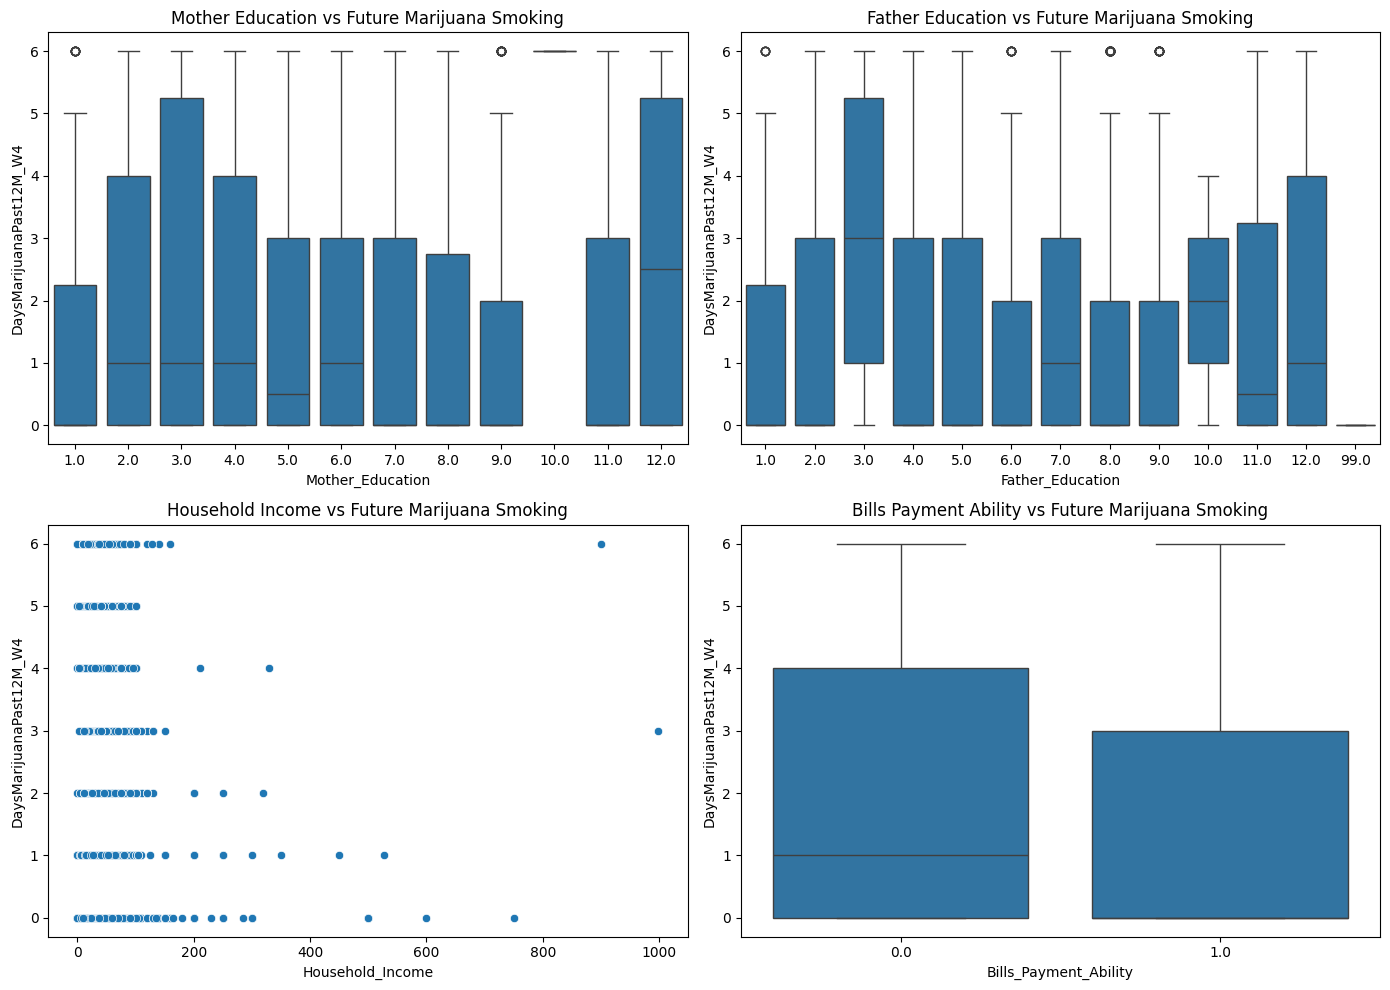

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.boxplot(x='Mother_Education', y=dep, data=df1, ax=axes[0,0])
axes[0,0].set_title('Mother Education vs Future Marijuana Smoking')

sns.boxplot(x='Father_Education', y=dep, data=df1, ax=axes[0,1])
axes[0,1].set_title('Father Education vs Future Marijuana Smoking')

sns.scatterplot(x='Household_Income', y=dep, data=df1, ax=axes[1,0])
axes[1,0].set_title('Household Income vs Future Marijuana Smoking')

# Boxplot only for Bills Payment Ability
sns.boxplot(x='Bills_Payment_Ability', y=dep, data=df1, ax=axes[1,1])
axes[1,1].set_title('Bills Payment Ability vs Future Marijuana Smoking')

plt.tight_layout()
plt.show()


## Suicide

In [541]:
df1["SuicidalIdeation"] = df1["H1SU1"].replace({
    6: np.nan, 8: np.nan, 9: np.nan
})
df1["SuicideAttempts"] = df1["H1SU2"].replace({
    6: np.nan, 7: np.nan, 8: np.nan, 9: np.nan
})


In [50]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
suicide_vars=['SuicidalIdeation','SuicideAttempts']
rows = []

for v in suicide_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))


           Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
0  SuicidalIdeation             0.042  2194         0.211       1.235   
1   SuicideAttempts            -0.071   387         0.013       1.013   

   Ordinal_p  
0      0.042  
1      0.901  


Suicidal ideation showed a modest but statistically significant association with future marijuana use, whereas suicide attempts were not associated. This suggests that marijuana use may co-occur with explaining psychological distress rather than with severe or acute self-harm behavior.

## Neighborhood

In [565]:
df1["BuildingType"] = df1["H1IR10"]
df1["BuildingCondition"] = df1["H1IR11"].replace({
    '6': np.nan, '8': np.nan, '9': np.nan
})
df1["NeighborhoodType"] = df1["H1IR12"].replace({
    '96': np.nan, '98': np.nan, '99': np.nan
})
df1["StreetCondition"] = df1["H1IR14"].replace({
    '6': np.nan, '97': np.nan, '98': np.nan, '99': np.nan
})
df1["InterviewerUnsafe"] = df1["H1IR15"].replace({
    '6': np.nan, '8': np.nan, '9': np.nan
})


In [170]:
df1 = df1.rename(columns={
    "H1NB1": "KnowNeighbors_W1",
    "H1NB2": "TalkToNeighbors_W1",
    "H1NB3": "NeighborsLookOut_W1",
    "H1NB5": "FeelSafeNeighborhood_W1",
    "H1NB6": "HappyNeighborhood_W1"
})

In [171]:
# 2. Columns to clean
cols = [
    "KnowNeighbors_W1",
    "TalkToNeighbors_W1",
    "NeighborsLookOut_W1",
    "FeelSafeNeighborhood_W1",
    "HappyNeighborhood_W1"
]

# 3. Convert to numeric + replace 6, 8, 9 with NaN
df1[cols] = df1[cols].apply(pd.to_numeric, errors='coerce')
df1[cols] = df1[cols].replace({6: np.nan, 8: np.nan, 9: np.nan})

In [54]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
# Base neighborhood perception variables
vars_to_use = [
    "KnowNeighbors_W1",
    "TalkToNeighbors_W1",
    "NeighborsLookOut_W1",
    "FeelSafeNeighborhood_W1",
    "HappyNeighborhood_W1",
    "BuildingCondition",
    "StreetCondition",
    "InterviewerUnsafe"
]



print("Variables used:")
print(vars_to_use)

rows = []

for v in vars_to_use:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))


Variables used:
['KnowNeighbors_W1', 'TalkToNeighbors_W1', 'NeighborsLookOut_W1', 'FeelSafeNeighborhood_W1', 'HappyNeighborhood_W1', 'BuildingCondition', 'StreetCondition', 'InterviewerUnsafe']
                  Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
5        BuildingCondition             0.054  2178         0.139       1.149   
6          StreetCondition             0.037  1604         0.113       1.119   
2      NeighborsLookOut_W1             0.027  2169         0.103       1.108   
3  FeelSafeNeighborhood_W1             0.017  2209        -0.104       0.901   
0         KnowNeighbors_W1             0.002  2208        -0.042       0.959   
7        InterviewerUnsafe            -0.009  2188        -0.000       1.000   
4     HappyNeighborhood_W1            -0.016  2209        -0.054       0.948   
1       TalkToNeighbors_W1            -0.030  2208        -0.102       0.903   

   Ordinal_p  
5      0.005  
6      0.071  
2      0.261  
3      0.456  
0      0.6

Exploratory analyses of neighborhood and built-environment characteristics revealed generally weak associations with future marijuana use. Among the examined variables, building condition showed a modest positive association (OR ≈ 1.15, p = 0.005), suggesting slightly higher odds of marijuana use in poorer physical housing conditions. Street condition exhibited a similar but weaker pattern that did not reach conventional levels of statistical significance. In contrast, neighborhood social cohesion and safety measures, including knowing neighbors, talking to neighbors, perceptions that neighbors look out for one another, feeling safe in the neighborhood, and overall neighborhood happiness, were not significantly associated with future marijuana use. Overall, these findings indicate that structural aspects of the built environment may play a limited role, while subjective neighborhood social perceptions show little independent association with marijuana use trajectories in this sample.

## Violence

In [175]:
df1 = df1.rename(columns={
    "H1FV1": "SawViolentAttack_W1",
    "H1FV2": "WeaponThreat_W1",
    "H1FV5": "PhysicalFight_W1",
    "H1FV6": "Jumped_W1"
})


In [56]:
viol_vars = [
    "SawViolentAttack_W1",
    "WeaponThreat_W1",
    "PhysicalFight_W1",
    "Jumped_W1"
]

for v in viol_vars:
    print(v, df1[v].unique())


SawViolentAttack_W1 [ 0.  1.  2. nan]
WeaponThreat_W1 [ 0.  1.  2. nan]
PhysicalFight_W1 [ 0.  1.  2. nan]
Jumped_W1 [ 0.  1.  2. nan]


In [177]:
df1[viol_vars] = df1[viol_vars].replace([6,8], np.nan)
df1[viol_vars] = df1[viol_vars].apply(pd.to_numeric, errors="coerce")


In [57]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel


rows = []

for v in viol_vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))


              Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
1      WeaponThreat_W1             0.089  2203         0.273       1.314   
2     PhysicalFight_W1             0.076  2203         0.200       1.221   
0  SawViolentAttack_W1             0.050  2200         0.281       1.325   
3            Jumped_W1             0.006  2203         0.007       1.007   

   Ordinal_p  
1      0.001  
2      0.000  
0      0.000  
3      0.932  


The exposure to violence is modestly but consistently associated with future marijuana use. WeaponThreat_W1, SawViolentAttack_W1, and PhysicalFight_W1 all showed statistically significant positive associations, with odds ratios ranging from approximately 1.22 to 1.33, suggesting higher likelihood of marijuana use among adolescents exposed to direct or witnessed violence. In contrast, Jumped_W1 was not associated with future marijuana use, indicating that not all forms of victimization carry the same relevance. Overall, these results suggest that exposure to aggressive or threatening environments, rather than victimization alone, is more closely linked to marijuana use trajectories.

## INterviewer on Respondent Behavior

In [186]:
df1["BoredImpatient"] = df1["H1IR19"].replace({
    '6': np.nan, '8': np.nan, '9': np.nan
})
df1["Embarrassed"] = df1["H1IR21"].replace({
    '6': np.nan, '8': np.nan, '9': np.nan
})
df1["AppearedIntoxicated"] = df1["H1IR18"].replace({
    '6': np.nan, '8': np.nan, '9': np.nan
})


In [193]:
df1["BoredImpatient"] = df1["BoredImpatient"].replace({
    6: np.nan, 8: np.nan, 9: np.nan
})
df1["Embarrassed"] = df1["Embarrassed"].replace({
    6: np.nan, 8: np.nan, 9: np.nan
})
df1["AppearedIntoxicated"] = df1["AppearedIntoxicated"].replace({
    6: np.nan, 8: np.nan, 9: np.nan
})

In [59]:

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
# Interviewer Ratings
vars=[
    "AppearedIntoxicated",
    "BoredImpatient",
    "Embarrassed"]

rows = []

for v in vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))

   


              Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
0  AppearedIntoxicated             0.030  2210         0.504       1.656   
2          Embarrassed             0.016  2208        -0.008       0.992   
1       BoredImpatient            -0.003  2210        -0.061       0.941   

   Ordinal_p  
0      0.090  
2      0.957  
1      0.624  


## Social life

In [326]:
rename_da = {
    "H1DA7": "HangoutFriends_W1",
    "H1DA8": "HoursTV_W1",
    "H1DA10": "HoursGames_W1"
}

df1 = df1.rename(columns=rename_da)


In [201]:
vars_da = ["HangoutFriends_W1", "HoursTV_W1", "HoursGames_W1"]

for v in vars_da:
    print("\n-----", v, "-----")
    print(df1[v].unique())



----- HangoutFriends_W1 -----
[ 3.  2.  1.  0. nan]

----- HoursTV_W1 -----
[33. 24. 14. 35. 10.  0.  7. 15.  4. 56. 77.  8. 26. 20. 49.  6. 40. 21.
 28.  5. 72. 25.  2. 70. 16. 30.  1. 12. 48.  9. 23.  3. 22. 42. 36. 18.
 98. 65. 90. 60. 11. 74. 84. 50. 19. 51. 63. 80. 45. 32. 96. 99. 78. 13.
 nan 27. 75. 17. 64. 91. 37. 29. 46. 68. 54. 52. 85. 44. 69. 38. 34. 47.
 76. 86. 55. 31. 57.]

----- HoursGames_W1 -----
[ 0.  7.  3.  2.  4.  1.  5.  6. 10.  8. 21. 20. 50.  9. 60. 12. 25. 18.
 14. 24. 15. 49. 35. 84. 99. 30. 28. 11. 26. 70. 16. nan 42. 96. 45. 40.
 34. 13. 19. 48. 32. 17. 23. 64. 37.]


In [202]:
df1["HangoutFriends_W1"] = df1["HangoutFriends_W1"].replace([6, 8], np.nan)
df1["HoursTV_W1"]   = df1["HoursTV_W1"].replace([996, 998], np.nan)
df1["HoursGames_W1"] = df1["HoursGames_W1"].replace([996, 998], np.nan)


In [203]:
df1[vars_da].describe()


,HangoutFriends_W1,HoursTV_W1,HoursGames_W1
count,5110.000000,5097.000000,5106.000000
mean,1.977104,16.228958,2.779867
std,1.001889,15.191968,6.559463
min,0.000000,0.000000,0.000000
25%,1.000000,5.000000,0.000000
50%,2.000000,12.000000,1.000000
75%,3.000000,21.000000,3.000000
max,3.000000,99.000000,99.000000


In [60]:

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
vars_da = ["HangoutFriends_W1", "HoursTV_W1", "HoursGames_W1"]

rows = []

for v in vars_da:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))

   
 


            Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
2      HoursGames_W1             0.074  2209         0.014       1.014   
0  HangoutFriends_W1             0.057  2209         0.082       1.086   
1         HoursTV_W1             0.047  2207         0.007       1.007   

   Ordinal_p  
2      0.010  
0      0.048  
1      0.007  


Time spent playing video games (HoursGames_W1) and watching television (HoursTV_W1) were each associated with slightly higher odds of marijuana use, while spending more time hanging out with friends (HangoutFriends_W1) showed a similarly modest positive association. However, effect sizes were minimal (odds ratios close to 1), indicating that these activities explain very limited variation in marijuana use. Overall, these findings suggest that time use patterns are weak correlates, and that leisure activities alone are unlikely to play a substantive role in shaping marijuana use trajectories compared to social and environmental exposures.

## Health

In [207]:
df1['Maturity_Male'] = df1['H1MP4'].replace([6,7,8,9], np.nan)
df1['Maturity_Female'] = df1['H1FP6'].replace([6,7,8,9], np.nan)
df1['PerceivedMaturity_W1'] = np.where(
    df1['Sex_Female'] == 1,
    df1['Maturity_Female'],
    df1['Maturity_Male']
)


In [211]:
rename_gh = {
    "H1GH18":  "SleepTrouble_W1",
    "H1GH20":  "Moodiness_W1",
    "H1GH22":  "Fearfulness_W1",
    "H1GH53":  "NightAway_W1",
    "H1GH28":  "WeightPerception_W1",
    "H1GH31C": "LiftWeights_W1"
}

df1 = df1.rename(columns=rename_gh)


In [212]:
vars_gh = list(rename_gh.values())

for v in vars_gh:
    print("\n-----", v, "-----")
    print(df1[v].unique())



----- SleepTrouble_W1 -----
[0 2 1 3 4 8 6]

----- Moodiness_W1 -----
[4 1 3 2 0 8 6]

----- Fearfulness_W1 -----
[1 0 2 4 3 8 6]

----- NightAway_W1 -----
[0 1 9 6 8]

----- WeightPerception_W1 -----
[5 2 4 3 1 8 6]

----- LiftWeights_W1 -----
[7 1 0]


In [213]:
df1[vars_gh] = df1[vars_gh].replace([6, 7, 8, 9], np.nan)

In [214]:
for v in vars_gh:
    print("\n", v, df1[v].unique())



 SleepTrouble_W1 [ 0.  2.  1.  3.  4. nan]

 Moodiness_W1 [ 4.  1.  3.  2.  0. nan]

 Fearfulness_W1 [ 1.  0.  2.  4.  3. nan]

 NightAway_W1 [ 0.  1. nan]

 WeightPerception_W1 [ 5.  2.  4.  3.  1. nan]

 LiftWeights_W1 [nan  1.  0.]


In [217]:
df1 = df1.rename(columns={"H1HS3": "Counseling_W1"})


In [218]:
print(df1["Counseling_W1"].unique())


[0 1 8 6]


In [219]:
df1["Counseling_W1"] = df1["Counseling_W1"].replace([6,8], np.nan)


In [220]:
print(df1["Counseling_W1"].unique())


[ 0.  1. nan]


In [62]:

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
vars=['Maturity_Male','Maturity_Female',"SleepTrouble_W1",
     "Moodiness_W1",
    "Fearfulness_W1",
    "NightAway_W1",
    "WeightPerception_W1",
    "LiftWeights_W1","Counseling_W1"]

rows = []

for v in vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))

   
 


              Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
5         NightAway_W1             0.079  2207         0.391       1.478   
3         Moodiness_W1             0.051  2207         0.055       1.056   
1      Maturity_Female             0.027  1035        -0.007       0.993   
7       LiftWeights_W1             0.011   442         0.093       1.097   
2      SleepTrouble_W1             0.002  2209        -0.010       0.990   
4       Fearfulness_W1            -0.007  2208        -0.017       0.983   
6  WeightPerception_W1            -0.012  2208        -0.002       0.998   
8        Counseling_W1            -0.018  2208         0.028       1.029   
0        Maturity_Male            -0.052  1157        -0.053       0.948   

   Ordinal_p  
5      0.000  
3      0.157  
1      0.900  
7      0.597  
2      0.783  
4      0.772  
6      0.968  
8      0.787  
0      0.260  


Most individual-level traits showed little association with future marijuana use. The exception was NightAway_W1, which demonstrated a moderate positive association (OR ≈ 1.48, p < 0.001), suggesting higher odds of marijuana use among adolescents who spent nights away from home. Measures related to mood, sleep problems, fearfulness, body-weight perceptions, and counseling utilization were not significantly associated with marijuana use. Similarly, perceived maturity—measured separately for males and females—showed no meaningful relationship. Overall, these findings suggest that behavioral autonomy and unsupervised time, rather than internal psychological states or self-perceptions, are more relevant correlates of marijuana use in this exploratory analysis.

## Future Aspirations

In [223]:
df1 = df1.rename(columns={
    "H1EE1": "WantCollege_W1",
    "H1EE2": "ExpectCollege_W1"
})


In [224]:
clean_6_8 = [6, 8]

df1[["WantCollege_W1", "ExpectCollege_W1"]] = \
    df1[["WantCollege_W1", "ExpectCollege_W1"]].replace(clean_6_8, np.nan)


In [63]:

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
vars=["WantCollege_W1", "ExpectCollege_W1"]

rows = []

for v in vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))

   
 


           Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
0    WantCollege_W1            -0.035  2208        -0.036       0.964   
1  ExpectCollege_W1            -0.079  2207        -0.102       0.903   

   Ordinal_p  
0      0.349  
1      0.003  


Exploratory analyses of educational orientation indicated that expectations, rather than aspirations, were associated with future marijuana use. ExpectCollege_W1 showed a modest but statistically significant negative association (OR ≈ 0.90, p = 0.003), indicating lower odds of marijuana use among adolescents who expected to attend college. In contrast, WantCollege_W1 was not significantly associated with marijuana use. These findings suggest that realistic educational expectations, rather than abstract aspirations, may function as a protective factor in marijuana use trajectories.

## Work

In [233]:
df1 = df1.rename(columns={
    "H1EE3": "WorkedForPay_W1",
    "H1EE4": "HoursWorked_W1"
})


In [234]:
df1["WorkedForPay_W1"] = df1["WorkedForPay_W1"].replace([6, 8], np.nan)
df1["HoursWorked_W1"] = df1["HoursWorked_W1"].replace([996, 998, 999], np.nan)



In [64]:

import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
vars=["WorkedForPay_W1",
     "HoursWorked_W1"]

rows = []

for v in vars:
    # ===== Weighted Spearman =====
    temp = df1[[v, dep, "Weight"]].copy()

    temp[v]        = pd.to_numeric(temp[v], errors="coerce")
    temp[dep]      = pd.to_numeric(temp[dep], errors="coerce")
    temp["Weight"] = pd.to_numeric(temp["Weight"], errors="coerce")

    temp = temp.dropna(subset=[v, dep, "Weight"])
    temp = temp[np.isfinite(temp["Weight"])]
    temp = temp[temp["Weight"] > 0]

    if temp.empty or temp[v].nunique() < 2 or temp[dep].nunique() < 2:
        continue

    rho = weighted_spearman(
        temp[v].to_numpy(),
        temp[dep].to_numpy(),
        temp["Weight"].to_numpy()
    )

    # ===== Ordered logit =====
    temp2 = df1[[v, dep]].copy()
    temp2[v]   = pd.to_numeric(temp2[v], errors="coerce")
    temp2[dep] = pd.to_numeric(temp2[dep], errors="coerce")
    temp2 = temp2.dropna(subset=[v, dep])

    y_ord = temp2[dep].astype(int)
    X = temp2[[v]]

    try:
        res = OrderedModel(
            y_ord,
            X,
            distr="logit"
        ).fit(method="bfgs", maxiter=1000, disp=False)

        beta = float(res.params[v])
        OR   = float(np.exp(beta))
        pval = float(res.pvalues[v])
        n    = int(temp2.shape[0])

    except Exception:
        beta, OR, pval, n = np.nan, np.nan, np.nan, int(temp2.shape[0])

    rows.append({
        "Variable": v,
        "WeightedSpearman": rho,
        "N": n,
        "Ordinal_beta": beta,
        "Ordinal_OR": OR,
        "Ordinal_p": pval
    })

results_suicide = (
    pd.DataFrame(rows)
      .sort_values("WeightedSpearman", ascending=False)
)

print(results_suicide.round(3))

   
 


          Variable  WeightedSpearman     N  Ordinal_beta  Ordinal_OR  \
1   HoursWorked_W1            -0.020  2196        -0.005       0.995   
0  WorkedForPay_W1            -0.055  2208        -0.177       0.838   

   Ordinal_p  
1      0.123  
0      0.028  


Working for pay was modestly associated with lower odds of future marijuana use (OR ≈ 0.84, p = 0.028). In contrast, the number of hours worked per week was not significantly associated with marijuana use. These findings suggest that participation in paid work, rather than work intensity, may have a small protective association with marijuana use, potentially reflecting greater structure or responsibility.

## more indices

In [231]:
df1["HighEduExpectations"] = (
    (df1["WantCollege_W1"] >= 3) &
    (df1["ExpectCollege_W1"] >= 3)
).astype(int)


In [236]:
neigh_vars = [ "KnowNeighbors_W1",
    "TalkToNeighbors_W1",
    "NeighborsLookOut_W1",
    "FeelSafeNeighborhood_W1",
     "HappyNeighborhood_W1"
             ]


df1["NeighborhoodCohesion_Index"] = df1[neigh_vars].mean(axis=1)


In [237]:
df1["ParentalSupport_Index"] = (
    df1[["ParentCare_W1",
         "ParentalWarmth_Index",
         ]]
    .mean(axis=1)
)


In [238]:
df1["Support_Index"] = (
    df1[["ParentCare_W1",
         "ParentalWarmth_Index",
         'AdultCare_W1',              
             
'FriendCare_W1' ,            
'TeacherCare_W1' ]]
    .mean(axis=1)
)


In [264]:
# lowreligiousityindex
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df1['LowImportance_Z'] = scaler.fit_transform(df1[['LowReligiousImportance']])
df1['LessAttendance_Z'] = scaler.fit_transform(df1[['LessReligiousServiceAttendance_W1']])
df1['LowReligiosityIndex_W1'] = df1[['LowImportance_Z', 'LessAttendance_Z']].mean(axis=1)


In [265]:
from sklearn.preprocessing import StandardScaler

# Define variables for this index
mental_vars = ["UnfriendlyPeople", "HardToStart", "NotWorthLiving"]

# Standardize
scaler = StandardScaler()
df1[[v + "_Z" for v in mental_vars]] = scaler.fit_transform(df1[mental_vars])

# Create the index
df1["MentalDistress_Index"] = df1[[v + "_Z" for v in mental_vars]].mean(axis=1)


In [266]:
from sklearn.preprocessing import StandardScaler

# SES variable list
ses_vars = [
    "Mother_Education",
    "Father_Education",
    "Household_Income",
    "Bills_Payment_Ability"
]

# Standardize
scaler = StandardScaler()
df1[[v + "_Z" for v in ses_vars]] = scaler.fit_transform(df1[ses_vars])

# SES index = mean of Z-scores
df1["SES_Index"] = df1[[v + "_Z" for v in ses_vars]].mean(axis=1)


In [267]:
from sklearn.preprocessing import StandardScaler

substance_vars = [
    "EverTried_Cigarette",
    "EverSmoked_Regularly",
    "Age_StartedSmoking",       # reverse-code
    "Days_SmokedPast30",
    "CigsPerDay_Past30",
    "DrinkWithoutAdults",
    "Age_FirstDrinkNoAdults",   # reverse-code
    "DrinkFrequency_Past12mo",
    "DrinksPerOccasion_Past12mo",
    
]

# Standardize all variables first
scaler = StandardScaler()
df1[[v + "_Z" for v in substance_vars]] = scaler.fit_transform(df1[substance_vars])

# Reverse-code the age variables
df1["Age_StartedSmoking_rev_Z"] = -df1["Age_StartedSmoking_Z"]
df1["Age_FirstDrinkNoAdults_rev_Z"] = -df1["Age_FirstDrinkNoAdults_Z"]

# Build list of variables to include in final index
substance_vars_final = [
    "EverTried_Cigarette_Z",
    "EverSmoked_Regularly_Z",
    "Age_StartedSmoking_rev_Z",
    "Days_SmokedPast30_Z",
    "CigsPerDay_Past30_Z",
    "DrinkWithoutAdults_Z",
    "Age_FirstDrinkNoAdults_rev_Z",
    "DrinkFrequency_Past12mo_Z",
    "DrinksPerOccasion_Past12mo_Z",
    
]

# Create final composite index
df1["SubstanceUse_Index"] = df1[substance_vars_final].mean(axis=1)

In [268]:
from sklearn.preprocessing import StandardScaler

sex_vars = [
    "FriendsRespect_Sex",
    "Rev_FeelGuilty_Sex",      # already reversed in your data
    "Rev_UpsetMother_Sex",     # already reversed in your data
    "Pleasure_Sex",
    "Relax_Sex",
    "Attractive_Sex",
    "LessLonely_Sex"
]

# Standardize
scaler = StandardScaler()
df1[[v + "_Z" for v in sex_vars]] = scaler.fit_transform(df1[sex_vars])

# Build final index
df1["SexAttitudes_Index"] = df1[[v + "_Z" for v in sex_vars]].mean(axis=1)


In [269]:
from sklearn.preprocessing import StandardScaler

# Variables in the School Behavior Index
school_vars = [
    "TimesSkippedSchool",
    "SchoolCloseness",          # already high=bad, low=good
    "SchoolSuspension",
    "SchoolExpulsion",
    "SchoolTrouble_Index"
]

# Standardize all variables
scaler = StandardScaler()
df1[[v + "_Z" for v in school_vars]] = scaler.fit_transform(df1[school_vars])

# Build final composite index
school_vars_final = [v + "_Z" for v in school_vars]

df1["SchoolBehavior_Index"] = df1[school_vars_final].mean(axis=1)


In [270]:
# 1. Tobacco Use Index
tobacco_vars = [
    "EverTried_Cigarette_Z",
    "EverSmoked_Regularly_Z",
    "Age_StartedSmoking_rev_Z",
    "Days_SmokedPast30_Z",
    "CigsPerDay_Past30_Z"
]
df1["TobaccoUse_Index"] = df1[tobacco_vars].mean(axis=1)

# 2. Alcohol Use Index
alcohol_vars = [
    "DrinkWithoutAdults_Z",
    "Age_FirstDrinkNoAdults_rev_Z",
    "DrinkFrequency_Past12mo_Z",
    "DrinksPerOccasion_Past12mo_Z",
    "peer_alcohol_count"
]
df1["AlcoholUse_Index"] = df1[alcohol_vars].mean(axis=1)

# 3. Peer Substance Use Index
peer_vars = [
    "PeerCig_Count",
    "PeerWeed_Count",
    "peer_alcohol_count"
]
df1["PeerSubstance_Index"] = df1[peer_vars].mean(axis=1)

# 4. Home Drug Risk / Drug Environment Index
home_vars = [
    "Age_FirstMarijuana",
    "Lifetime_Marijuana",
    "Age_FirstCocaine",
    "AlcoholAvailable_Home",
    "DrugsAvailable_Home",
    "GunAvailable_Home"
]
df1["HomeDrugRisk_Index"] = df1[home_vars].mean(axis=1)


## Vars

In [ ]:
keep_vars = [
    "Race",
    "Age at First Drink",
    "TotalDrinking",
    "Age when Moved to Current Residence",
    "BirthYear",
    "Hours of Sleep",
    "Trouble Paying Attention",
    "ReligionGroup",
    "LowReligiousImportance",
    "TimesSkippedSchool",
    "SchoolCloseness",
    "SchoolSuspension",
    "SchoolExpulsion",
    "peer_alcohol_any",

    "FriendsRespect_Sex",
    "Rev_FeelGuilty_Sex",
    "Rev_UpsetMother_Sex",
    "Pleasure_Sex",
    "Relax_Sex",
    "Attractive_Sex",
    "LessLonely_Sex",

    "Fight_Serious",
    "InjuredSomeone",
    "DroveWithoutPermission",
    "WeaponUse_Threat",
    "SoldDrugs",
    "GroupFight",
    "PublicRowdy",
    "LiedToParents",

    "EverTried_Cigarette",
    "EverSmoked_Regularly",
    "Age_StartedSmoking",
    "Days_SmokedPast30",
    "CigsPerDay_Past30",
    "DrinkWithoutAdults",
    "Age_FirstDrinkNoAdults",
    "DrinkFrequency_Past12mo",
    "DrinksPerOccasion_Past12mo",

    "Mother_Education",
    "Father_Education",
    "Household_Income",
    "Bills_Payment_Ability",

    "SportsParticipation_Index",

    "BluesInspiteOfHelp",
    "LessThanOthers",
    "Unhappy",
    "Lonely",
    "UnfriendlyPeople",
    "HardToStart",
    "NotWorthLiving",

    "SchoolTrouble_Index",
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index"
]

df_f = df1[keep_vars].copy()

In [538]:

#df_f.to_csv("df_f_bestmarijuana.csv", index=False)

In [26]:
import os
os.chdir('D://My_projects//Drug Use//capstone')

In [518]:
keep_vars = [
     
       "DaysMarijuanaPast12M_W4",
  'Sex_Female',
    "BirthYear",
 #    "Age at First Drink",
    
    "Trouble Paying Attention",
    'ReligiosityIndex_W1',
#  'ReligiousServiceAttendance_W1',
#    "LowReligiousImportance",
   

   "Age_FirstMarijuana",
    
  
    "PeerCig_Count",
    "PeerWeed_Count",
   "peer_alcohol_count",
    
   'Fight_Serious',
     'InjuredSomeone',
     'DroveWithoutPermission',
     'WeaponUse_Threat',
     'SoldDrugs',
     'GroupFight',
     'PublicRowdy',
     'LiedToParents',

    
    "Age_FirstDrinkNoAdults_rev_Z",
   # "DrinkFrequency_Past12mo_Z",
    "DrinksPerOccasion_Past12mo_Z",
   
   # "Age_StartedSmoking_rev_Z",
    
   "BluesInspiteOfHelp",
    "LessThanOthers",
    "Unhappy",
    "Lonely",
    "UnfriendlyPeople",
    "HardToStart",
    "NotWorthLiving",

  

    "FriendsRespect_Sex",
    "Rev_FeelGuilty_Sex",
    "Rev_UpsetMother_Sex",
    "SexAttitudes_Index",
    

#"ParentalSupport_Index",
  # "Support_Index",
    "GPA_Index",
# "ParentalWarmth_Index",
 # "ClosenessToMotherAlt_W1",
#  "MotherCares_W1",
#  "ClosenessToFatherAlt_W1",
#  "FatherCares_W1",
    "ParentalSupervision_Index",
     
  
    
    
   
  

  


   
      
    
'BuildingType',

'BuildingCondition',

'NeighborhoodType',

'StreetCondition',
   
 "BoredImpatient",
   #"Embarrassed",
    "SuicidalIdeation",
  # "SuicideAttempts",

#"SchoolBehavior_Index",
"SES_Index",
'NightAway_W1',
'Moodiness_W1',
   # 'HangoutFriends_W1',          
#'HoursTV_W1',
#'HoursGames_W1',
    #"SelfRatedIntelligence_W1",
#'SchoolTaught_Smoking_W1',     
#'SchoolTaught_Drinking_W1',
   # "Counseling_W1"
    #'TroubleConcentrating_W1',
#'FeelingDepressed_W1',
#'BirthOrder_W1',
#   'MotherEverSmoked_W1',
#'ClosenessToMother_W1', 
#   'FatherEverSmoked_W1',
#'ClosenessToFather_W1',
#    'ProudOfYourself_rev',
#'LikeYourself_rev',
   # 'SawViolentAttack_W1',       
   # 'WeaponThreat_W1',            
'PhysicalFight_W1',          
'Jumped_W1',
  #  'PerceivedMaturity_W1',
 #   'WantLeaveHome_W1',           
#'AdultCare_W1',              
#'ParentCare_W1',             
#'FriendCare_W1' ,            
#'TeacherCare_W1' ,
    

"NeighborhoodCohesion_Index",
 'WantCollege_W1',
'ExpectCollege_W1'
]
df_f = df1[keep_vars].copy()




In [542]:
keep_vars=['WorkedForPay_W1',           
'HoursWorked_W1' ]
df_f = df1[ keep_vars + df_best.columns.tolist() ]


In [41]:
import os 
os.chdir('D://My_projects//Drug Use//capstone')

In [544]:
#df_f.to_csv("df_f_Marijuana.csv", index=False)

In [545]:
#df1.drop(columns=["DaysMarijuanaPast12M_W4"]).to_csv("df1_allvar.csv", index=False)



In [271]:
df1['LowReligiousImportance'].describe()

count    4443.000000
mean        1.628854
std         0.751553
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: LowReligiousImportance, dtype: float64

In [525]:
#df_best=pd.read_csv('df_f_bestmarijuana.csv')

In [60]:
df1.shape

(2210, 2925)